# Neural activity data analysis

Analysis of experimental spike-train data using Python. The notebook explores neuronal activity across multiple experimental conditions and aligns spike times to relevant behavioral/experimental events.

## Dataset structure

The input table used by the original analysis contains the following fields: `Neurona`, `T_spike`, `Trial`, `T_entrada`, `T_salida`, `T_inhala`, `Ensayo`, and `T_inicio`.

> **Data availability:** the original dataset is not included in this repository unless publication permission has been confirmed. To reproduce the notebook, place the corresponding file at `data/data.csv`.

## Analysis workflow

- Raster plots aligned to context entry, inhalation and context exit.
- Firing-rate estimation for individual neurons and population-level activity.
- Comparison of activity across experimental conditions.
- Pearson correlation analysis and neuron-by-neuron correlation matrices.
- Exploratory classification of neuronal responses.
- Functional-network representations based on correlation thresholds.
- Lagged cross-correlation analysis for selected neuronal pairs.

## Python stack

`NumPy` · `Pandas` · `Matplotlib` · `Seaborn` · `SciPy` · `NetworkX`


# Librerias y Seteo de Gráficos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import networkx as nx

plt.rcParams.update({'legend.fontsize': 22})
plt.rcParams.update({'axes.titlesize': 22})
plt.rcParams.update({'axes.labelsize': 24})
plt.rcParams.update({'ytick.labelsize': 24})
plt.rcParams.update({'xtick.labelsize': 24})
plt.rcParams.update({'legend.loc':"best"})
plt.rcParams.update({"figure.figsize": [9, 7]})
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.grid'] = True
plt.rcParams['font.family'] = 'STIXGeneral'


# Cargar Datos

In [ ]:

ruta = '../data/data.csv'
df = pd.read_csv(ruta, header=None)

df.columns = [
    'Neurona', 'T_spike', 'Trial',
    'T_entrada', 'T_salida',
    'T_inhala', 'Ensayo', 'T_inicio'
]

colores = {
    1: 'red', 2: 'darkorange', 3: 'gold',
    4: 'darkgreen', 5: 'royalblue', 6: 'purple'
}

tipos_ensayo = {
    1: 'CR OR', 2: 'CU OR', 3: 'CR OU',
    4: 'CU OU', 5: 'CR', 6: 'CU'
}


Downloading...
From: https://drive.google.com/uc?id=1jZ7-gQMbMHRkprrEV1-6la47J9g6Fux0
To: /content/data.csv
100% 79.9M/79.9M [00:01<00:00, 73.9MB/s]


In [ ]:
df

,Neurona,T_spike,Trial,T_entrada,T_salida,T_inhala,Ensayo,T_inicio
0,1,0.241200,1,12.2264,16.496367,12.622600,1,0.000000
1,1,0.359000,1,12.2264,16.496367,12.622600,1,0.000000
2,1,0.374667,1,12.2264,16.496367,12.622600,1,0.000000
3,1,0.407400,1,12.2264,16.496367,12.622600,1,0.000000
4,1,0.487600,1,12.2264,16.496367,12.622600,1,0.000000
...,...,...,...,...,...,...,...,...
982907,64,3894.743633,176,3883.6013,3885.465000,3883.974367,1,3879.999667
982908,64,3894.984267,176,3883.6013,3885.465000,3883.974367,1,3879.999667
982909,64,3895.356433,176,3883.6013,3885.465000,3883.974367,1,3879.999667
982910,64,3895.464867,176,3883.6013,3885.465000,3883.974367,1,3879.999667


# Análisis por Neurona

In [ ]:
lista_neuronas = df['Neurona'].unique()
lista_neuronas

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64])

### Alineado a Entrada

In [ ]:


for id_neurona in lista_neuronas:

    datos_neurona = df[df['Neurona'] == id_neurona]
    ensayos = datos_neurona['Ensayo'].unique()

    fig, axs = plt.subplots(2, 1, figsize=(20, 16))

    for n in ensayos:

        ensayo_especifico = datos_neurona[datos_neurona["Ensayo"] == n]
        ensayo_especifico = ensayo_especifico.copy()
        ensayo_especifico['T_alineado'] = (
            ensayo_especifico['T_spike'] -
            ensayo_especifico['T_entrada']
        )

        axs[0].scatter(
            ensayo_especifico['T_alineado'],
            ensayo_especifico['Trial'],
            s=5, color=colores[n], marker='|',
            label=f'{tipos_ensayo[n]}'
        )

        axs[0].axvline(0, color='black', linestyle='--')
        axs[0].set_title(f"Raster Plot Alineado a la entrada al contexto- Neurona {id_neurona}")
        axs[0].set_xlabel("Tiempo relativo a la entrada (s)")
        axs[0].set_ylabel("Número de Trial")
        axs[0].legend()

        axs[0].set_xlim(-5, 5)
        axs[0].set_ylim(0, 100)


        # ---------- separando por trial ----------

        dt = 1e-4
        window = 500e-3
        half_w = window / 2

        bins = np.arange(-5 , 5 + dt, dt)
        t_vector = bins[:-1]
        kernel = np.ones(int(window / dt))

        rate_trials = []


        for tr in ensayo_especifico['Trial'].unique():
          spikes_trials = ensayo_especifico[
              ensayo_especifico['Trial'] == tr
          ]['T_alineado'].values

          counts,_ = np.histogram(spikes_trials, bins=bins)
          rate_tmp = np.convolve(counts, kernel, 'same')/window

          rate_trials.append(rate_tmp)

        rate_trials = np.array(rate_trials)
        rate = rate_trials.mean(axis=0)

        axs[1].plot(
            t_vector, rate - np.mean(rate),
            color=colores[n], label=f'{tipos_ensayo[n]}'
        )

        axs[1].axvline(0, color='black', linestyle='--')

        axs[1].set_title(f"Promedio de actividad alineado a la entrada al contexto - Neurona {id_neurona}")
        axs[1].set_xlabel("Tiempo relativo a la entrada (s)")
        axs[1].set_ylabel("Actividad")
        axs[1].legend()


Output hidden; open in https://colab.research.google.com to view.

### Alineado a Inhalación

In [ ]:
rates_por_neurona = {}

for id_neurona in lista_neuronas:

    datos_neurona = df[df['Neurona'] == id_neurona]
    ensayos = datos_neurona['Ensayo'].unique()

    rates_por_neurona[id_neurona] = {}

    fig, axs = plt.subplots(2, 1, figsize=(20, 16))

    for n in ensayos:

        ensayo_especifico = datos_neurona[datos_neurona["Ensayo"] == n]
        ensayo_especifico = ensayo_especifico.copy()
        ensayo_especifico['T_alineado'] = (
            ensayo_especifico['T_spike'] -
            ensayo_especifico['T_inhala']
        )

        axs[0].scatter(
            ensayo_especifico['T_alineado'],
            ensayo_especifico['Trial'],
            s=5, color=colores[n], marker='|',
            label=f'{tipos_ensayo[n]}'
        )

        axs[0].axvline(0, color='black', linestyle='--')
        axs[0].set_title(f"Raster Plot alineado al t de inhalación - Neurona {id_neurona}")
        axs[0].set_xlabel("Tiempo relativo a la entrada (s)")
        axs[0].set_ylabel("Número de Trial")

        axs[0].set_xlim(-2, 2)
        axs[0].set_ylim(0, 100)
        axs[0].legend()

        # ---------- separando por trial ----------

        dt = 5e-4
        window = 500e-3
        half_w = window / 2

        t_min, t_max = -2, 2

        bins = np.arange(t_min, t_max + dt, dt)
        t_vector = bins[:-1]
        kernel = np.ones(int(window / dt))

        trials = ensayo_especifico['Trial'].unique()
        rate_trials = np.zeros((len(trials), len(t_vector)))

        for k, tr in enumerate(trials):

            spikes_trial = ensayo_especifico[
                ensayo_especifico['Trial'] == tr
            ]['T_alineado'].values

            counts, _ = np.histogram(spikes_trial, bins=bins)

            rate_trials[k] = np.convolve(counts, kernel, 'same') / window

        rate_mean = rate_trials.mean(axis=0)

        axs[1].plot(
            t_vector, rate_mean,
            color=colores[n], label=f'{tipos_ensayo[n]}'
        )
        axs[1].axvline(0, color='black', linestyle='--')

        axs[1].set_title(f"Promedio de actividad alineado al t de inhalación - Neurona {id_neurona}")
        axs[1].set_xlabel("Tiempo relativo a la entrada (s)")
        axs[1].set_ylabel("Actividad")

        axs[1].legend()

        rates_por_neurona[id_neurona][n] = rate_trials.copy()


Output hidden; open in https://colab.research.google.com to view.

### Alineado a Salida

In [ ]:
for id_neurona in lista_neuronas:

    datos_neurona = df[df['Neurona'] == id_neurona]
    ensayos = datos_neurona['Ensayo'].unique()

    fig, axs = plt.subplots(2, 1, figsize=(20, 16))

    for n in ensayos:

        ensayo_especifico = datos_neurona[datos_neurona["Ensayo"] == n]
        ensayo_especifico = ensayo_especifico.copy()
        ensayo_especifico['T_alineado'] = (
            ensayo_especifico['T_spike'] -
            ensayo_especifico['T_salida']
        )

        axs[0].scatter(
            ensayo_especifico['T_alineado'],
            ensayo_especifico['Trial'],
            s=5, color=colores[n], marker='|',
            label=f'{tipos_ensayo[n]}'
        )

        axs[0].axvline(0, color='black', linestyle='--')

        axs[0].set_title(f"Raster Plot alineado al t de salida - Neurona {id_neurona}")
        axs[0].set_xlabel("Tiempo relativo a la salida (s)")
        axs[0].set_ylabel("Número de Trial")

        axs[0].set_xlim(-2, 2)
        axs[0].set_ylim(0, 100)
        axs[0].legend()

        # ---------- PSTH separando por trial ----------

        dt = 1e-4
        window = 500e-3
        half_w = window / 2

        t_min, t_max = -2, 2

        bins = np.arange(t_min, t_max + dt, dt)
        t_vector = bins[:-1]
        kernel = np.ones(int(window / dt))

        trials = ensayo_especifico['Trial'].unique()

        rate_trials = np.zeros((len(trials), len(t_vector)))

        for k, tr in enumerate(trials):

            spikes_trial = ensayo_especifico[ensayo_especifico['Trial'] == tr]['T_alineado'].values

            counts,_ = np.histogram(spikes_trial, bins=bins)
            rate_trials[k,:] = np.convolve(counts, kernel, 'same') / window


        rate = rate_trials.mean(axis=0)

        axs[1].plot(
            t_vector, rate,
            color=colores[n], label=f'{tipos_ensayo[n]}'
        )
        axs[1].axvline(0, color='black', linestyle='--')

        axs[1].set_title(f"Promedio de actividad alineado al t de salida - Neurona {id_neurona}")
        axs[1].set_xlabel("Tiempo relativo a la salida (s)")
        axs[1].set_ylabel("Actividad")

        axs[1].legend()


Output hidden; open in https://colab.research.google.com to view.

# Promedio de todas las neuronas

### Alineado a Salida

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


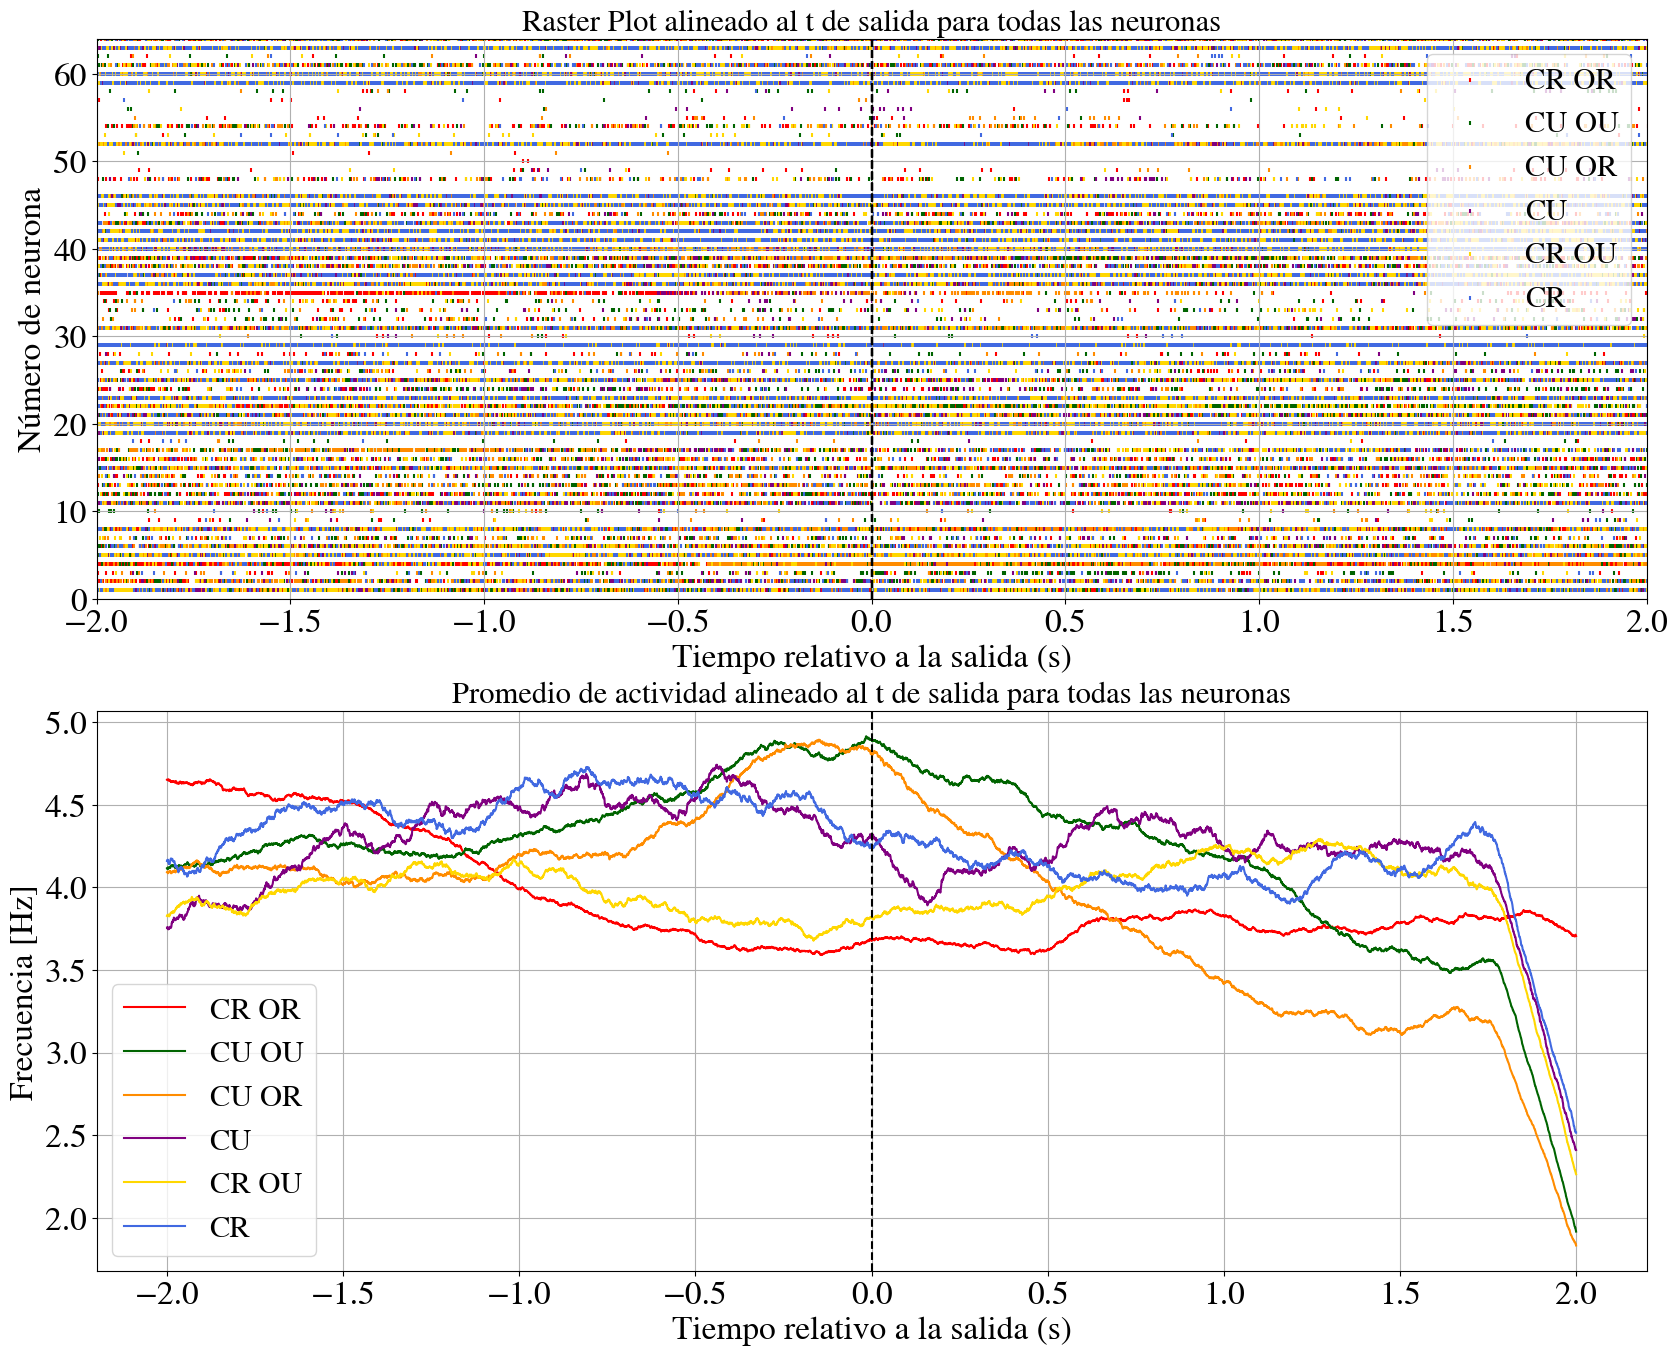

In [ ]:
fig, axs = plt.subplots(2,1, figsize=(20,16))

for ensayo_id in df['Ensayo'].unique():

    datos = df[df['Ensayo']==ensayo_id].copy()
    datos['T_alineado'] = datos['T_spike'] - datos['T_salida']

    axs[0].scatter(datos['T_alineado'], datos['Neurona'],
                   s=5, marker='|', color=colores[ensayo_id],
                   label=tipos_ensayo[ensayo_id])

    axs[0].axvline(x=0, color='black', linestyle='--')
    axs[0].set_title(f"Raster Plot alineado al t de salida para todas las neuronas" )
    axs[0].set_xlabel("Tiempo relativo a la salida (s)")
    axs[0].set_ylabel("Número de neurona")
    axs[0].legend()
    axs[0].set_xlim(-2,2)
    axs[0].set_ylim(0,64)

    dt = 5e-4
    window = 0.5
    half_w = window/2
    t_vector = np.arange(-2,2,dt)

    rate_all = []

    for tr in datos['Trial'].unique():
        for neu in datos['Neurona'].unique():

            spikes = datos[
                (datos['Trial']==tr)&(datos['Neurona']==neu)
            ]['T_alineado'].values

            rate_tmp = np.zeros_like(t_vector)

            for j,t in enumerate(t_vector):
                rate_tmp[j] = np.sum(
                    (spikes>=t-half_w)&(spikes<t+half_w)
                )/window

            rate_all.append(rate_tmp)

    rate = np.mean(rate_all, axis=0)

    axs[1].plot(t_vector, rate,
                color=colores[ensayo_id],
                label=tipos_ensayo[ensayo_id])

axs[0].axvline(0,color='k',ls='--')
axs[1].axvline(0,color='k',ls='--')

axs[1].set_title(f"Promedio de actividad alineado al t de salida para todas las neuronas")
axs[1].set_xlabel("Tiempo relativo a la salida (s)")
axs[1].set_ylabel("Frecuencia [Hz]")

axs[0].legend(); axs[1].legend()


### Alineado a Inhalación

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


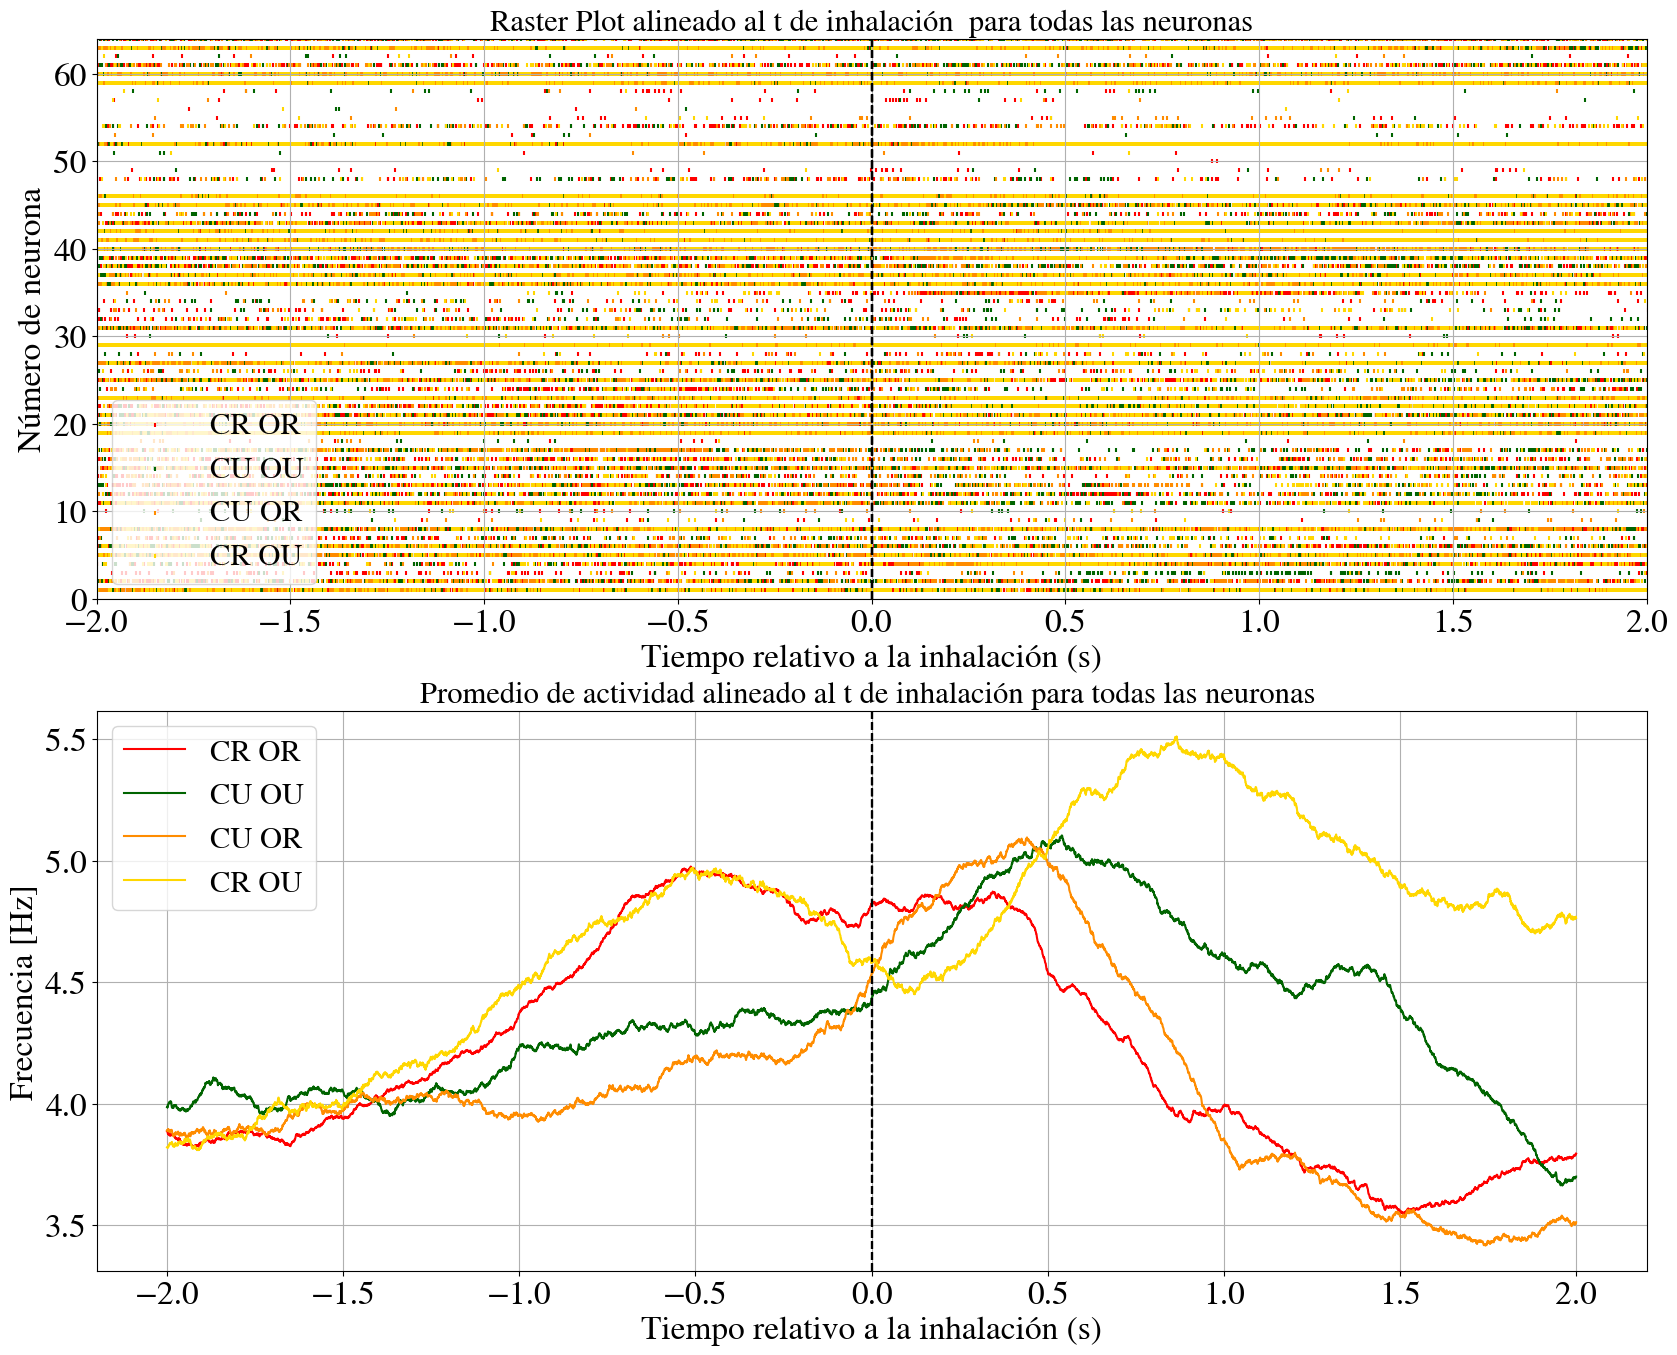

In [ ]:
actividad_poblacional = {}

fig, axs = plt.subplots(2,1, figsize=(20,16))

for ensayo_id in df['Ensayo'].unique():

  if (ensayo_id != 5) and (ensayo_id != 6):


    datos = df[df['Ensayo']==ensayo_id].copy()
    datos['T_alineado'] = datos['T_spike'] - datos['T_inhala']

    axs[0].scatter(datos['T_alineado'], datos['Neurona'],
                   s=5, marker='|', color=colores[ensayo_id],
                   label=tipos_ensayo[ensayo_id])

    axs[0].axvline(x=0, color='black', linestyle='--') #, label='Inicio (T_entrada)'
    axs[0].set_title(f"Raster Plot alineado al t de inhalación  para todas las neuronas") #- Ensayo {tipos_ensayo[ensayo_id]}
    axs[0].set_xlabel("Tiempo relativo a la inhalación (s)")
    axs[0].set_ylabel("Número de neurona")
    axs[0].legend()
    axs[0].set_xlim(-2,2) # delimitar cuánto tiempo queremos ver
    axs[0].set_ylim(0,64)


    dt = 5e-4
    window = 0.5
    half_w = window/2
    t_vector = np.arange(-2,2,dt)

    rate_all = []

    for tr in datos['Trial'].unique():
        for neu in datos['Neurona'].unique():

            spikes = datos[
                (datos['Trial']==tr)&(datos['Neurona']==neu)
            ]['T_alineado'].values

            rate_tmp = np.zeros_like(t_vector)

            for j,t in enumerate(t_vector):
                rate_tmp[j] = np.sum(
                    (spikes>=t-half_w)&(spikes<t+half_w)
                )/window

            rate_all.append(rate_tmp)

    actividad_poblacional[ensayo_id] = np.mean(rate_all, axis=0)

    axs[1].plot(t_vector, actividad_poblacional[ensayo_id],
                color=colores[ensayo_id],
                label=tipos_ensayo[ensayo_id])

    axs[0].axvline(0,color='k',ls='--')
    axs[1].axvline(0,color='k',ls='--')

    axs[1].set_title(f"Promedio de actividad alineado al t de inhalación para todas las neuronas ") #- Ensayo {tipos_ensayo[ensayo_id]}
    axs[1].set_xlabel("Tiempo relativo a la inhalación (s)")
    axs[1].set_ylabel("Frecuencia [Hz]")

    axs[0].legend(); axs[1].legend()



In [ ]:
actividad_poblacional

{np.int64(1): array([3.88740079, 3.88690476, 3.88492063, ..., 3.79464286, 3.79513889,
        3.79464286]),
 np.int64(4): array([3.98579545, 3.98768939, 3.98768939, ..., 3.6969697 , 3.69981061,
        3.69981061]),
 np.int64(2): array([3.8891129 , 3.89012097, 3.8921371 , ..., 3.50604839, 3.51209677,
        3.51209677]),
 np.int64(3): array([3.8203125 , 3.82161458, 3.82161458, ..., 4.76953125, 4.76692708,
        4.76432292])}

# Correlación

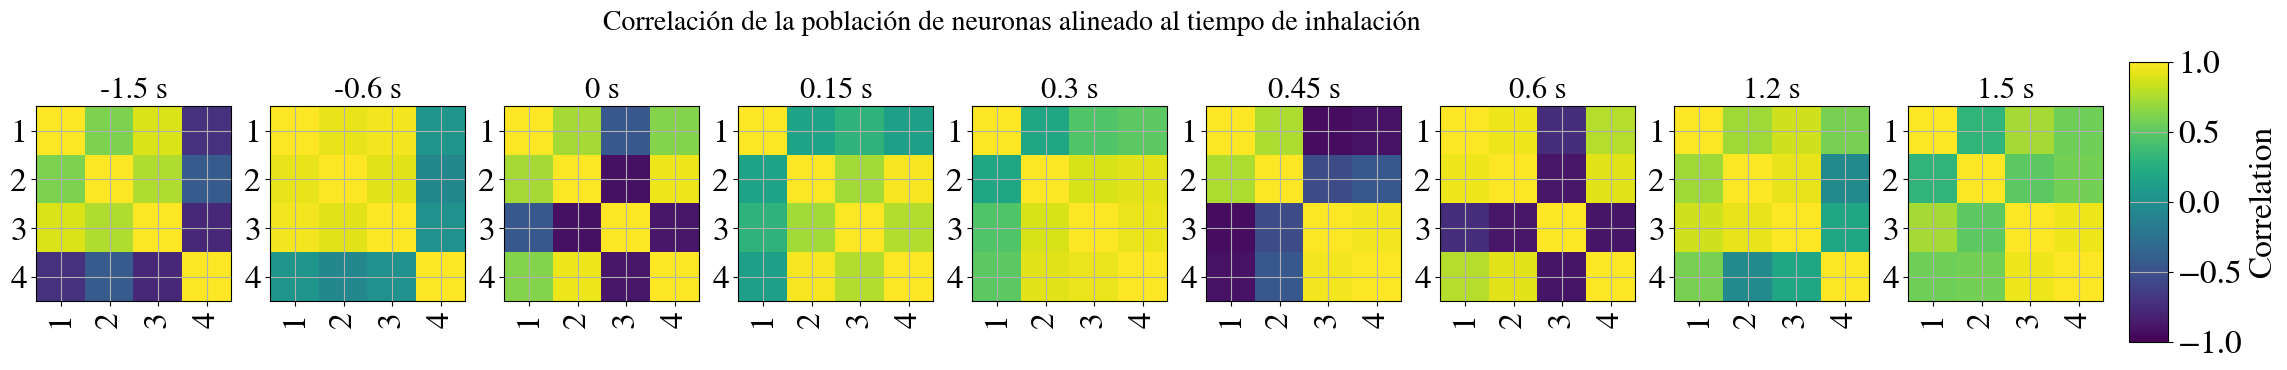

In [ ]:
tiempos = [-1.5, -0.6, 0, 0.15, 0.3, 0.45, 0.6, 1.2, 1.5]

ensayos_validos = sorted(actividad_poblacional.keys())
N = len(ensayos_validos)

fig, axs = plt.subplots(1, len(tiempos), figsize=(26,4))

for col, t0 in enumerate(tiempos):

    t_start = np.argmin(abs(t_vector - (t0 - 0.1)))
    t_end   = np.argmin(abs(t_vector - (t0 + 0.1)))

    M = np.zeros((N, N))

    for i, e1 in enumerate(ensayos_validos):
        for j, e2 in enumerate(ensayos_validos):

            v1 = actividad_poblacional[e1][t_start:t_end]
            v2 = actividad_poblacional[e2][t_start:t_end]

            M[i,j] = pearsonr(v1, v2)[0]

    im = axs[col].imshow(M, vmin=-1, vmax=1, cmap='viridis')
    axs[col].set_title(f"{t0} s")
    axs[col].set_xticks(range(N))
    axs[col].set_yticks(range(N))

    axs[col].set_xticklabels(ensayos_validos, rotation=90)
    axs[col].set_yticklabels(ensayos_validos)

    plt.suptitle(f'Correlación de la población de neuronas alineado al tiempo de inhalación', fontsize = 20)

plt.subplots_adjust(right=0.92)

cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Correlation")

plt.show()

# Una Propuesta Aparte Para Ver Tiempos

In [ ]:
respuesta = {}

dt = 1e-4                 # resolución temporal
window = 500e-3           # 500 ms
half_w = window / 2

t_min, t_max = -2, 2
bins = np.arange(t_min, t_max + dt, dt)
t_vector = bins[:-1] + dt / 2
kernel = np.ones(int(window / dt))

baseline_mask = (t_vector > -1.5) & (t_vector < -0.5)

for n in lista_neuronas:

    datos_neurona = df[df['Neurona'] == n]

    respuesta[f'Neurona {n}'] = {}

    for ensayo in datos_neurona['Ensayo'].unique():

        ensayo_especifico = datos_neurona[
            datos_neurona["Ensayo"] == ensayo
        ].copy()

        # Alineo a inhalación
        ensayo_especifico['T_alineado'] = (
            ensayo_especifico['T_spike'] -
            ensayo_especifico['T_inhala']
        )

        # ===== separando por trial =====

        rate_trials = []

        for tr in ensayo_especifico['Trial'].unique():

            spikes = ensayo_especifico[
                (ensayo_especifico['Trial'] == tr)&
                (ensayo_especifico['Ensayo'] == ensayo)
            ]['T_alineado'].values

            counts, _ = np.histogram(spikes, bins=bins)
            rate_tmp = np.convolve(counts, kernel, mode='same') / window
            rate_trials.append(rate_tmp)

        # Promedio entre trials
        rate_mean = np.mean(rate_trials, axis=0)

        # ===== Clasificación excitación / inhibición =====

        # Definir ventana basal

        mu_b = rate_mean[baseline_mask].mean()
        std_b = rate_mean[baseline_mask].std()

        if std_b == 0 or np.isnan(std_b):
          z_rate = np.zeros_like(rate_mean)
        else:
          z_rate = (rate_mean - mu_b) / std_b

        estado = np.zeros_like(z_rate, dtype=int)
        estado[z_rate >= 2] = 1     # excitación
        estado[z_rate <= -2] = -1   # inhibición

        respuesta[f'Neurona {n}'][f'ensayo {ensayo}'] = estado


In [ ]:
respuesta

{'Neurona 1': {'ensayo 1': array([-1, -1, -1, ..., -1, -1, -1]),
  'ensayo 4': array([-1, -1, -1, ..., -1, -1, -1]),
  'ensayo 2': array([ 0,  0,  0, ..., -1, -1, -1]),
  'ensayo 6': array([0, 0, 0, ..., 0, 0, 0]),
  'ensayo 3': array([-1, -1, -1, ...,  0,  0,  0]),
  'ensayo 5': array([0, 0, 0, ..., 0, 0, 0])},
 'Neurona 2': {'ensayo 1': array([-1, -1, -1, ..., -1, -1, -1]),
  'ensayo 4': array([-1, -1, -1, ..., -1, -1, -1]),
  'ensayo 2': array([-1, -1, -1, ..., -1, -1, -1]),
  'ensayo 6': array([0, 0, 0, ..., 0, 0, 0]),
  'ensayo 3': array([-1, -1, -1, ..., -1, -1, -1]),
  'ensayo 5': array([0, 0, 0, ..., 0, 0, 0])},
 'Neurona 3': {'ensayo 1': array([-1, -1, -1, ..., -1, -1, -1]),
  'ensayo 4': array([0, 0, 0, ..., 0, 0, 0]),
  'ensayo 6': array([0, 0, 0, ..., 0, 0, 0]),
  'ensayo 2': array([ 0,  0,  0, ..., -1, -1, -1]),
  'ensayo 3': array([-1, -1, -1, ..., -1, -1, -1]),
  'ensayo 5': array([0, 0, 0, ..., 0, 0, 0])},
 'Neurona 4': {'ensayo 1': array([0, 0, 0, ..., 0, 0, 0]),
  'en

### PLOT: TODAS LAS NEURONAS, TODOS LOS ENSAYOS

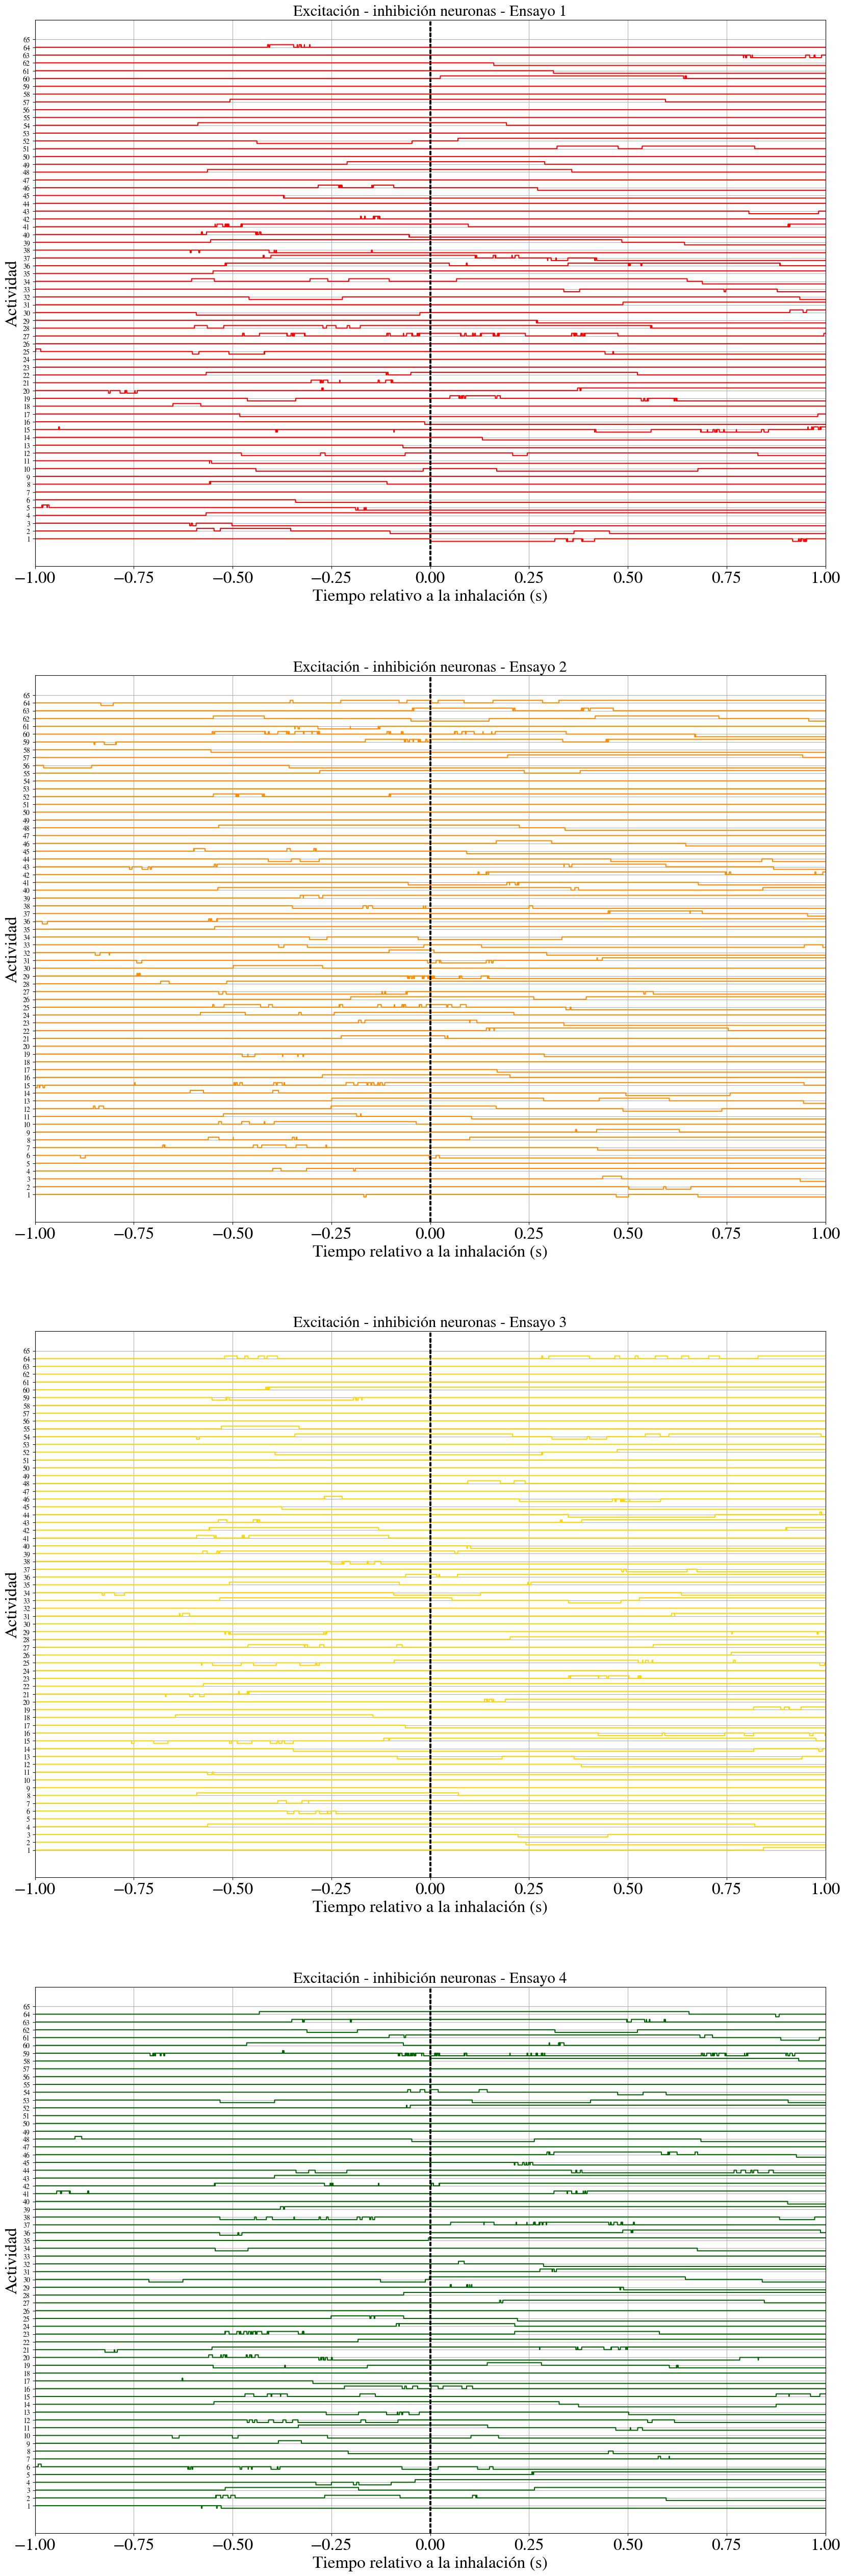

In [ ]:
fig, axs = plt.subplots(4,1, figsize=(20,64))

for n in range(1,65):
    for j in range(1,5):

        axs[j-1].plot(
            t_vector,
            np.array(respuesta[f'Neurona {n}'][f'ensayo {j}']) + n*3,
            color=colores[j]
        )

        axs[j-1].axvline(0, color='black', linestyle='--')
        axs[j-1].set_xlim(-1,1)
        axs[j-1].set_title(f"Excitación - inhibición neuronas - Ensayo {j}")
        axs[j-1].set_xlabel("Tiempo relativo a la inhalación (s)")
        axs[j-1].set_ylabel("Actividad")

        axs[j-1].set_yticks(np.arange(1,66)*3)
        axs[j-1].set_yticklabels(np.arange(1,66), fontsize=10)


### PLOT: EJEMPLO DE NEURONAS INDIVIDUALES

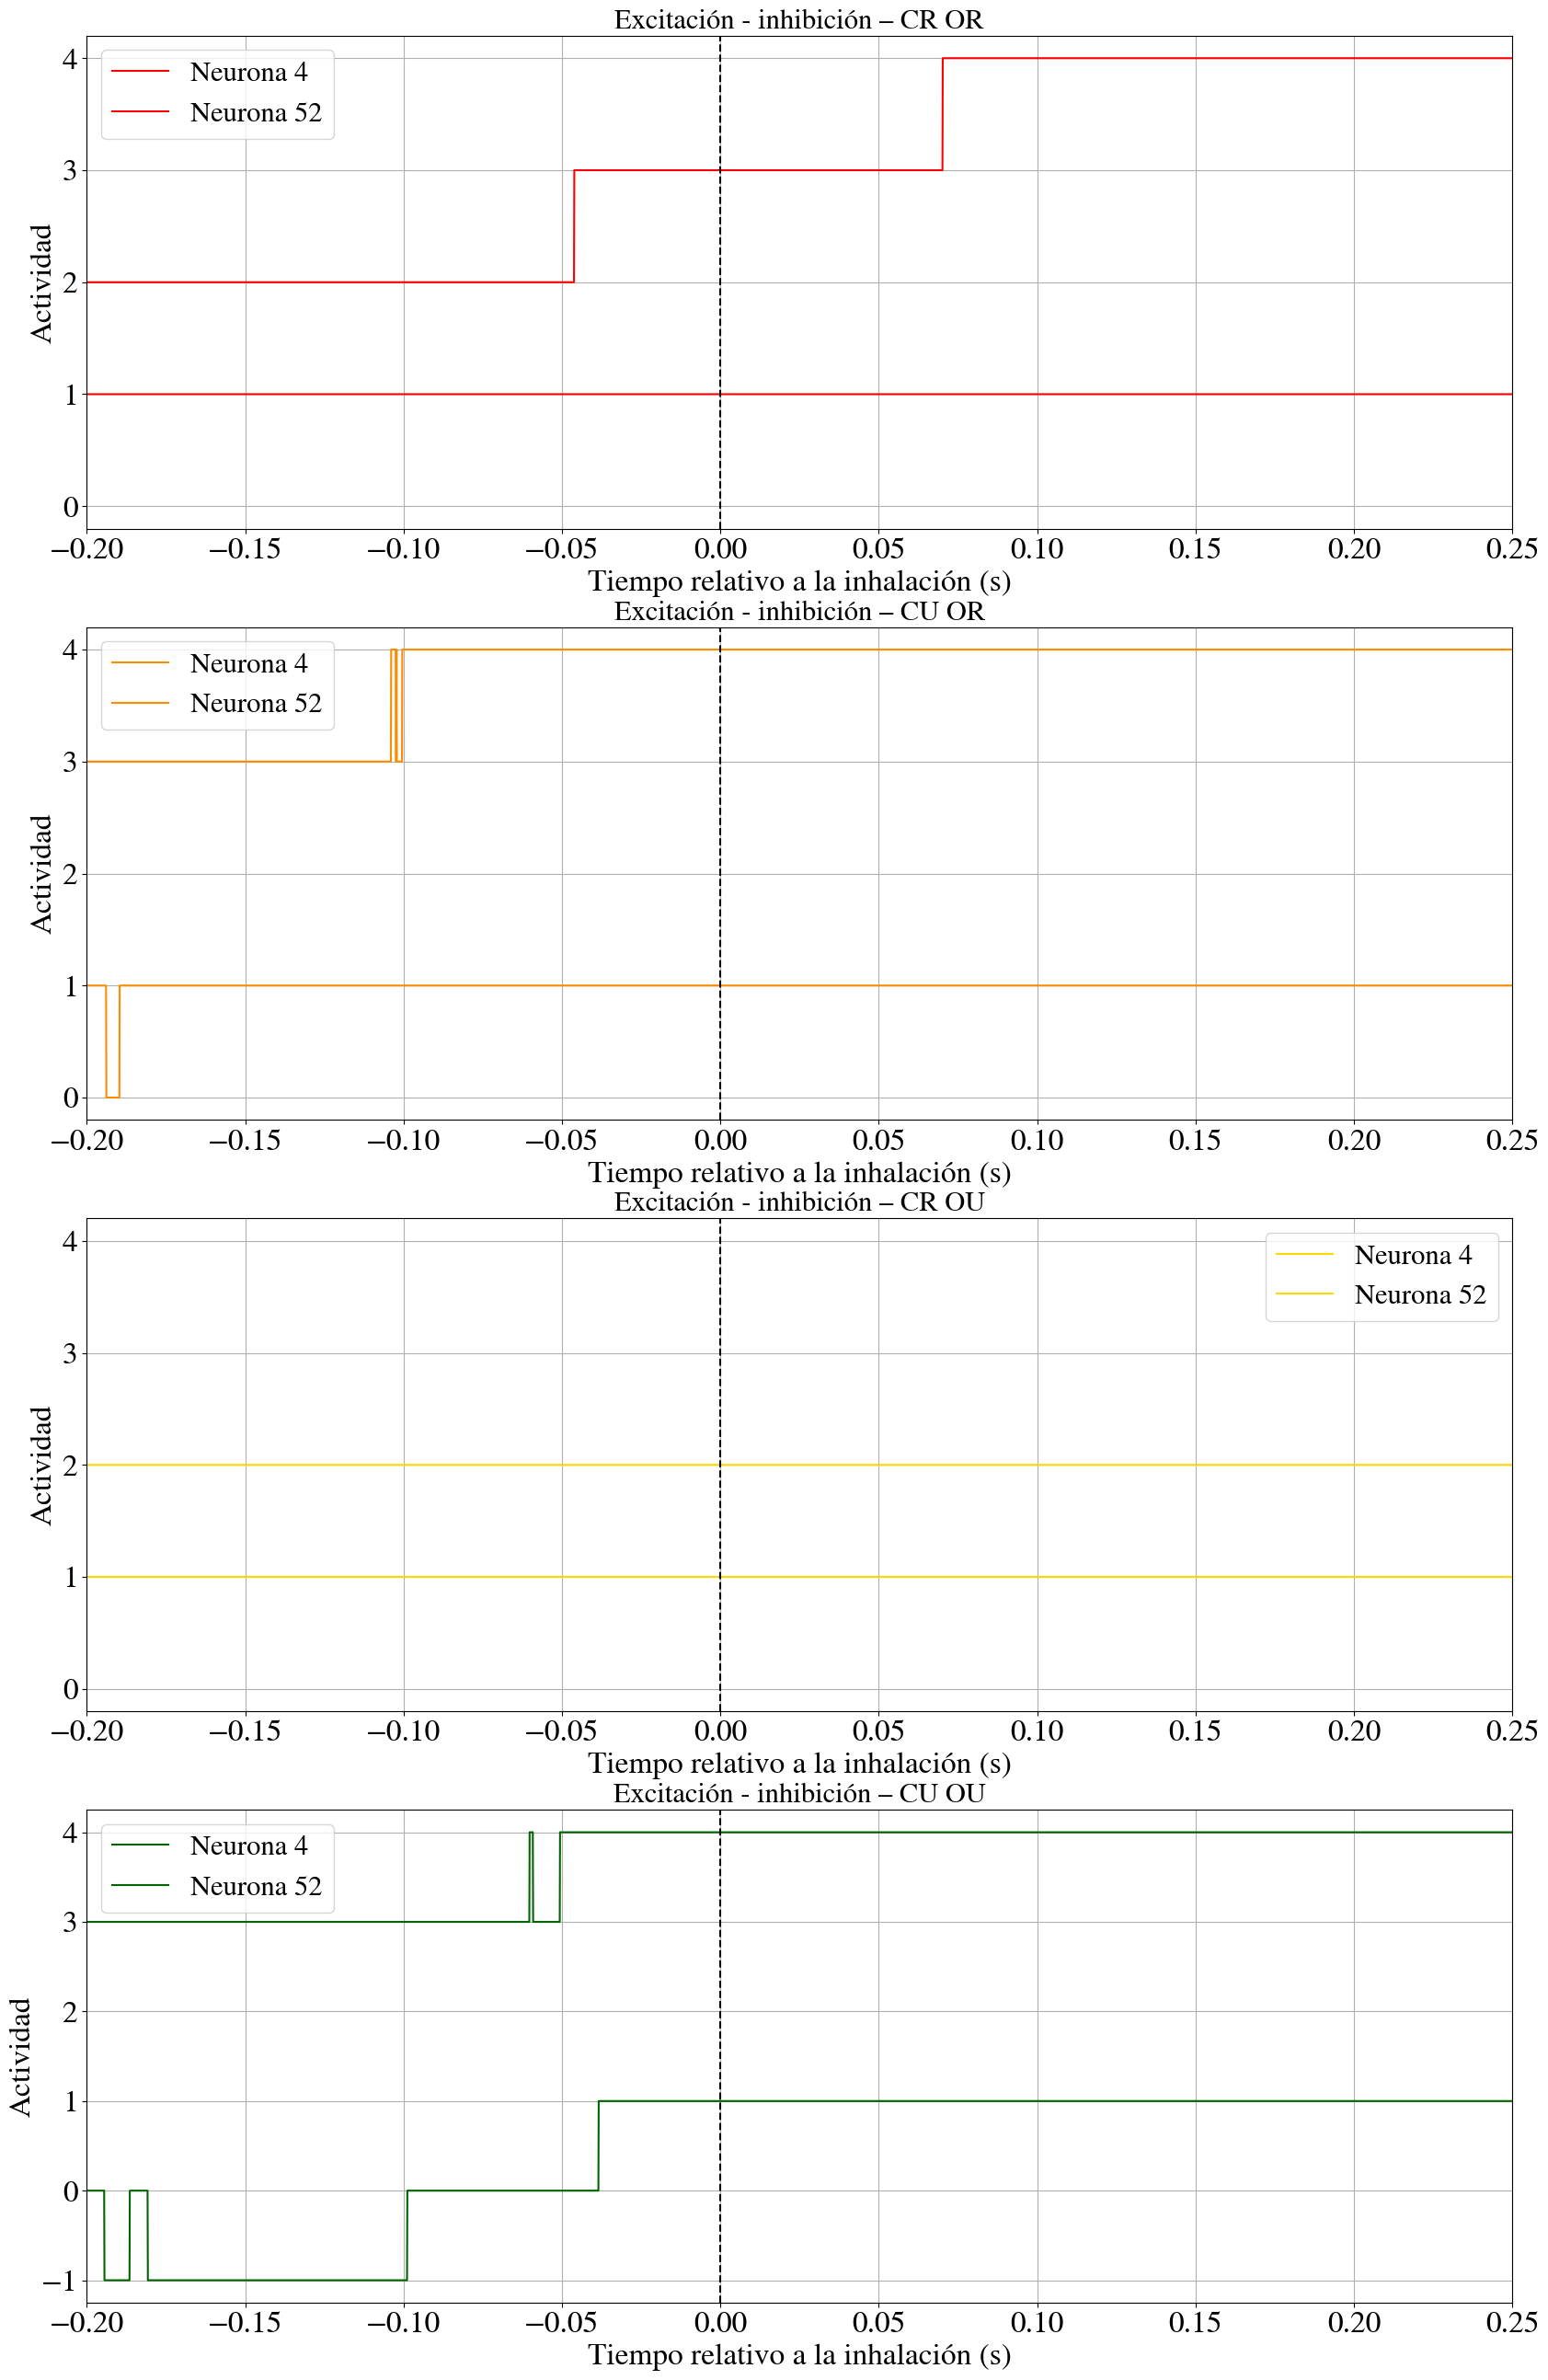

In [ ]:
fig, axs = plt.subplots(4,1, figsize=(20,32))

t_min = -2
t_max = 2
t_vector = np.arange(t_min, t_max, dt)

for j in range(1,5):

    axs[j-1].plot(
        t_vector,
        respuesta['Neurona 4'][f'ensayo {j}'],
        color=colores[j],
        label='Neurona 4'
    )

    axs[j-1].plot(
        t_vector,
        respuesta['Neurona 52'][f'ensayo {j}'] + 3,
        color=colores[j],
        label='Neurona 52'
    )

    axs[j-1].axvline(0, color='black', linestyle='--')
    axs[j-1].set_xlim(-0.2,0.25)
    axs[j-1].set_title(f"Excitación - inhibición – {tipos_ensayo[j]}")
    axs[j-1].set_xlabel("Tiempo relativo a la inhalación (s)")
    axs[j-1].set_ylabel("Actividad")

    axs[j-1].legend()



# MATRIZ DE CORRELACIÓN (FIRING RATE CONTINUO)

Se hace una análisis neurona-neurona, por separado para cada ensayo:
* Para cada par de neuronas:
  - Se correlacionó el firing rate (tasa de disparo) promedio dentro de una ventana temporal centrada en la inhalación
* Se obtuvo una matriz de correlación funcional por ensayo

In [ ]:
neuronas = sorted(rates_por_neurona.keys())
ensayos = sorted(rates_por_neurona[neuronas[0]].keys())

t0 = 0.0
window_corr = 1.0

dt = 5e-4
t_vector = np.arange(-2, 2, dt)

idx_start = np.argmin(np.abs(t_vector - (t0 - window_corr/2)))
idx_end   = np.argmin(np.abs(t_vector - (t0 + window_corr/2)))

corr_por_ensayo = {}
neuronas_usadas = {}

for ensayo in ensayos:

  # neuronas que SI tienen este ensayo
  neuronas_validas = [
      n for n in neuronas
      if ensayo in rates_por_neurona[n]
  ]


  N = len(neuronas_validas)
  corr_matrix = np.zeros((N, N))
  neuronas_usadas[ensayo] = neuronas_validas

  for i, ni in enumerate(neuronas_validas):
      for j, nj in enumerate(neuronas_validas):

          xi = rates_por_neurona[ni][ensayo].mean(axis=0)[idx_start:idx_end]
          xj = rates_por_neurona[nj][ensayo].mean(axis=0)[idx_start:idx_end]

          if np.std(xi) == 0 or np.std(xj) == 0:
              corr_matrix[i, j] = 0

          else:
              corr_matrix[i, j] = pearsonr(xi, xj)[0]

  np.fill_diagonal(corr_matrix, 1)
  corr_por_ensayo[ensayo] = corr_matrix

# Heatmap Correlación

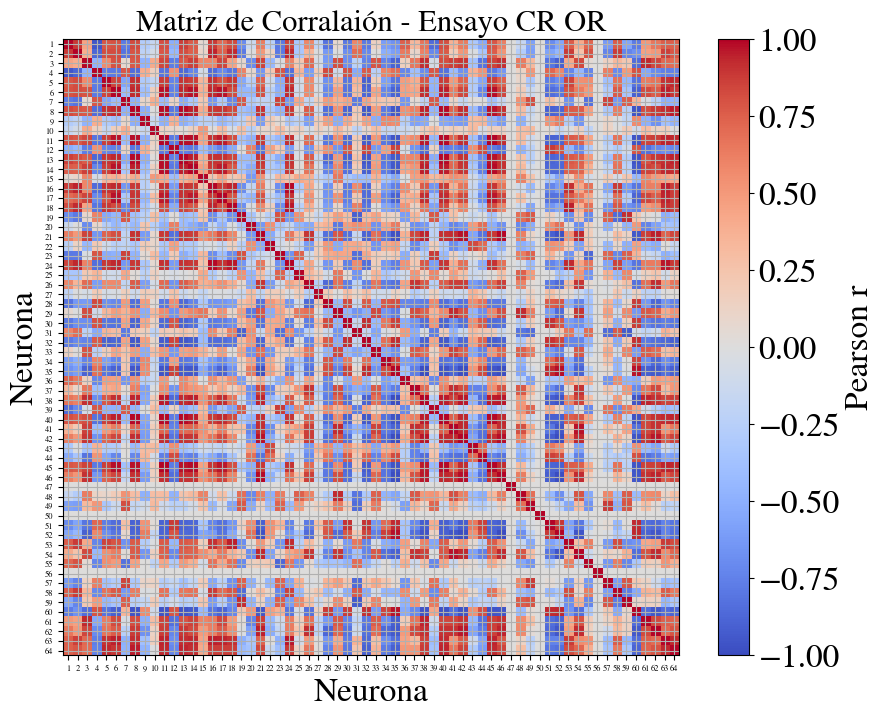

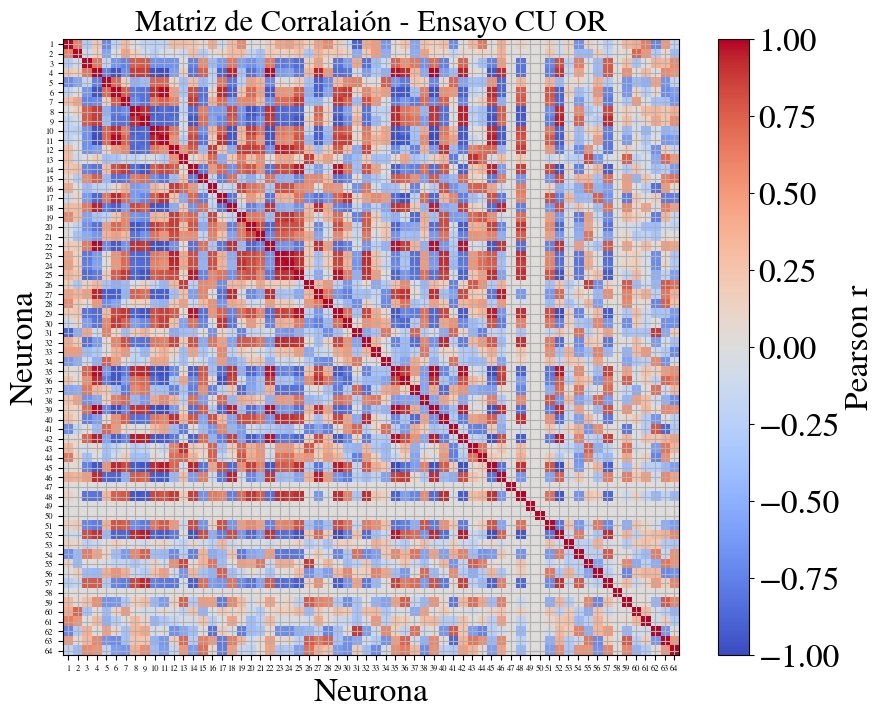

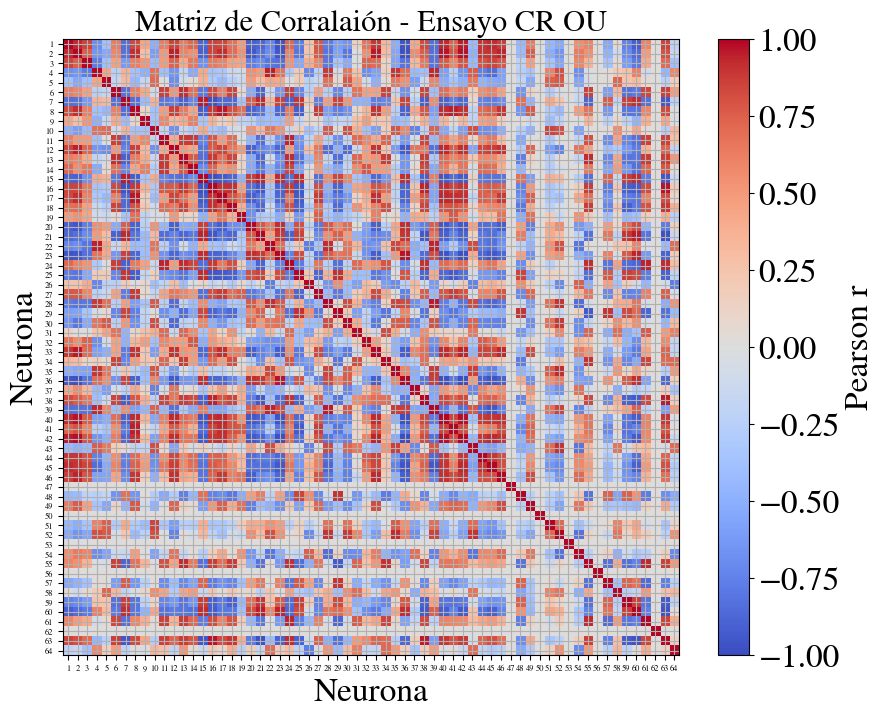

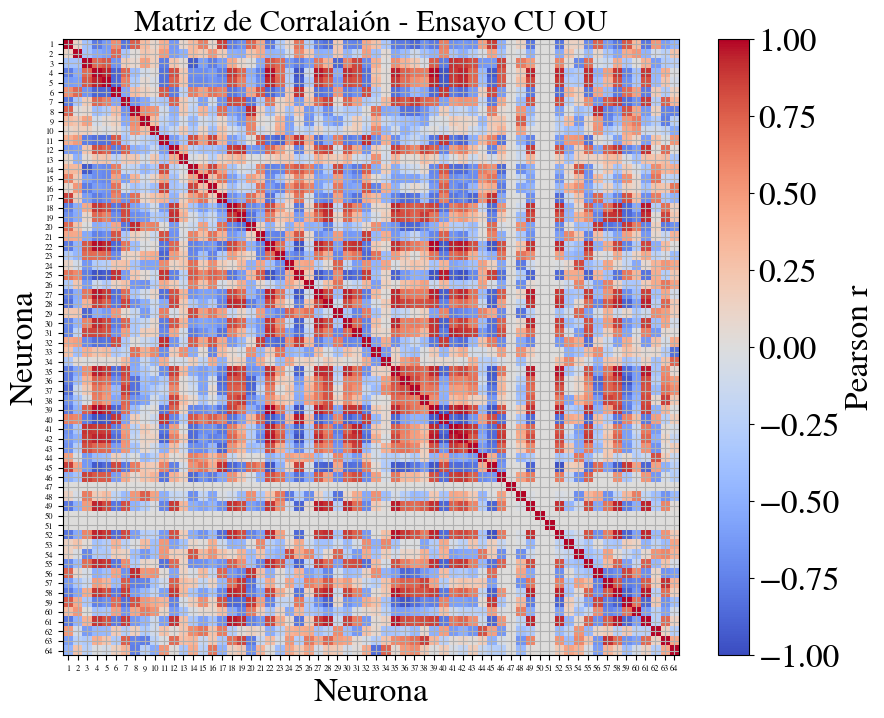

In [ ]:
ensayos = [1,2,3,4]

for ensayo in ensayos:

  neuronas_validas = neuronas_usadas[ensayo]

  corr_matrix = corr_por_ensayo[ensayo]


  plt.figure(figsize=(10,8))
  plt.imshow(corr_matrix, vmin=-1, vmax=1, cmap='coolwarm')
  plt.colorbar(label='Pearson r')
  plt.title(f'Matriz de Corralaión - Ensayo {tipos_ensayo[ensayo]}')
  plt.xlabel('Neurona')
  plt.ylabel('Neurona')

  plt.xticks(range(len(neuronas_validas)), neuronas_validas, fontsize=6)
  plt.yticks(range(len(neuronas_validas)), neuronas_validas, fontsize=6)

  plt.show()



# Clasificación de Neuronas

Cada fue clasificada según su respuesta al evento:
* Se usó la señal binaria:
  - +1 excitacón
  - 0 neutral
  - -1 inhibición
* La clasificación se realizó promediando el estado dentro de la ventana de interés.

Resultado:
* Cada neruona tiene un rol funcional dependinte del ensayo:
  - Excitatoria (E)
  - Inhibitoria (I)
  - Neutral (N)

In [ ]:
t0 = 0.0
window_corr = 1.0

dt = 5e-4
t_vector = np.arange(-2, 2, dt)

idx_start = np.argmin(np.abs(t_vector - (t0 - window_corr / 2)))
idx_end   = np.argmin(np.abs(t_vector - (t0 + window_corr / 2)))

tipo_neurona_por_ensayo  = {}

for ensayo, neuronas_validas in neuronas_usadas.items():

  tipo_neurona_por_ensayo[ensayo] = {}

  for n in neuronas_validas:

    estado = respuesta[f'Neurona {n}'][f'ensayo {ensayo}'][idx_start:idx_end]

    estado_promedio = estado.mean()

    if estado_promedio > 0.2:
        tipo_neurona_por_ensayo[ensayo][n] = 'E'   # excitatoria
    elif estado_promedio < -0.2:
        tipo_neurona_por_ensayo[ensayo][n] = 'I'   # inhibitoria
    else:
        tipo_neurona_por_ensayo[ensayo][n] = 'N'   # neutra

# Red Funcional

A partir de la matriz de correlación:
* Se construyó una red funcional neuronal por ensayo
* Nodos = neuronas
* Aristas = correlaciones fuertes (|r| > umbral)

In [ ]:
threshold_corr = 0.95
red_por_ensayo = {}

for ensayo in corr_por_ensayo.keys():

  corr_matrix = corr_por_ensayo[ensayo]
  neuronas_validas  = neuronas_usadas[ensayo]

  G = nx.DiGraph()

  for n in neuronas_validas:
      G.add_node(n, tipo = tipo_neurona_por_ensayo[ensayo][n])

  for i, ni in enumerate(neuronas_validas):
      for j, nj in enumerate(neuronas_validas):

        if i < j and abs(corr_matrix[i,j]) >= threshold_corr:
          G.add_edge(ni, nj,
                    weight= corr_matrix[i,j],
                    sign='+' if corr_matrix[i, j] > 0 else '-'
                    )
  red_por_ensayo[ensayo] = G

### Visualización de Red

* Layout circular para facilitar la interpretación
* Colores de nodos:
  - Rojo: excitatoria
  - Azul: inhibitoria
  - Gris: neutral

* Colores de aristas:
  - Verde: correlación positiva
  - Violeta: correlación negativa

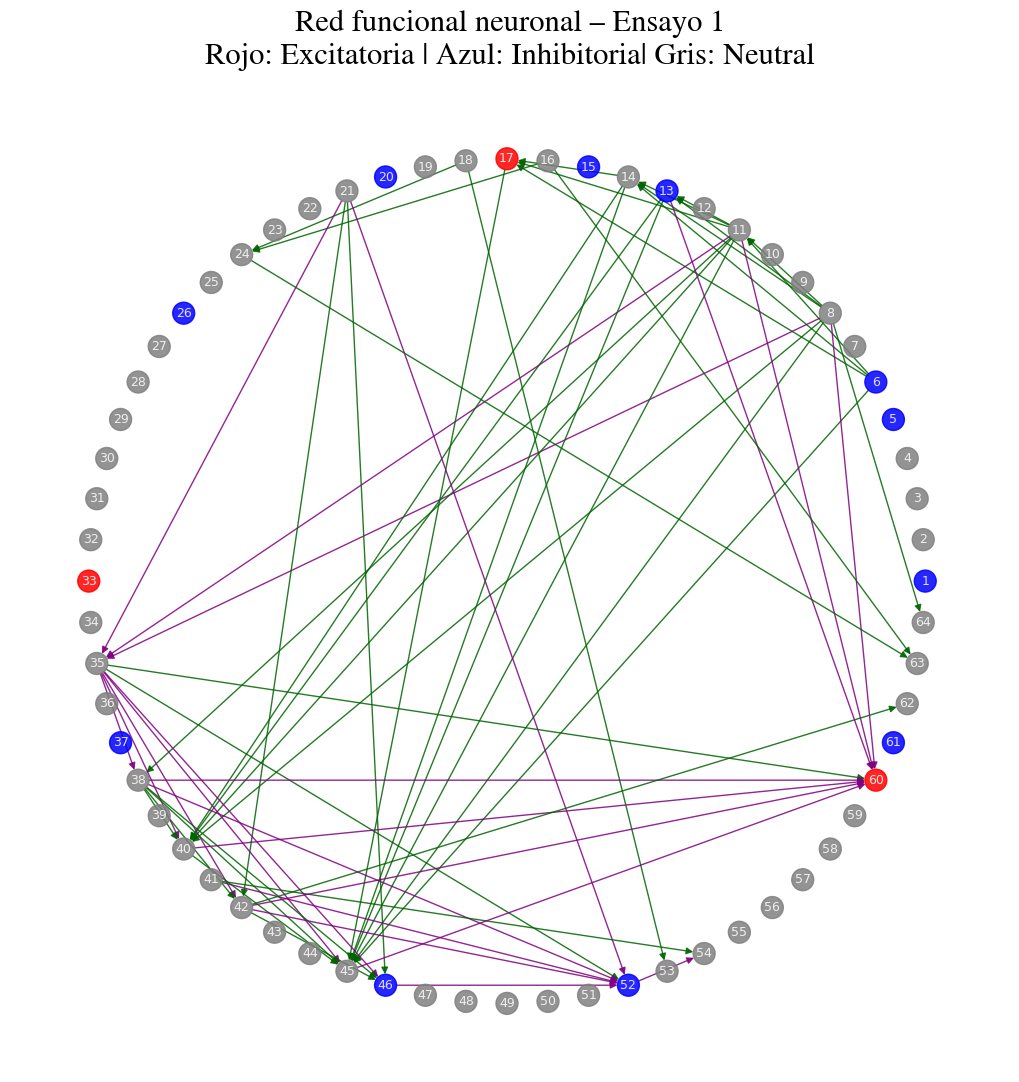

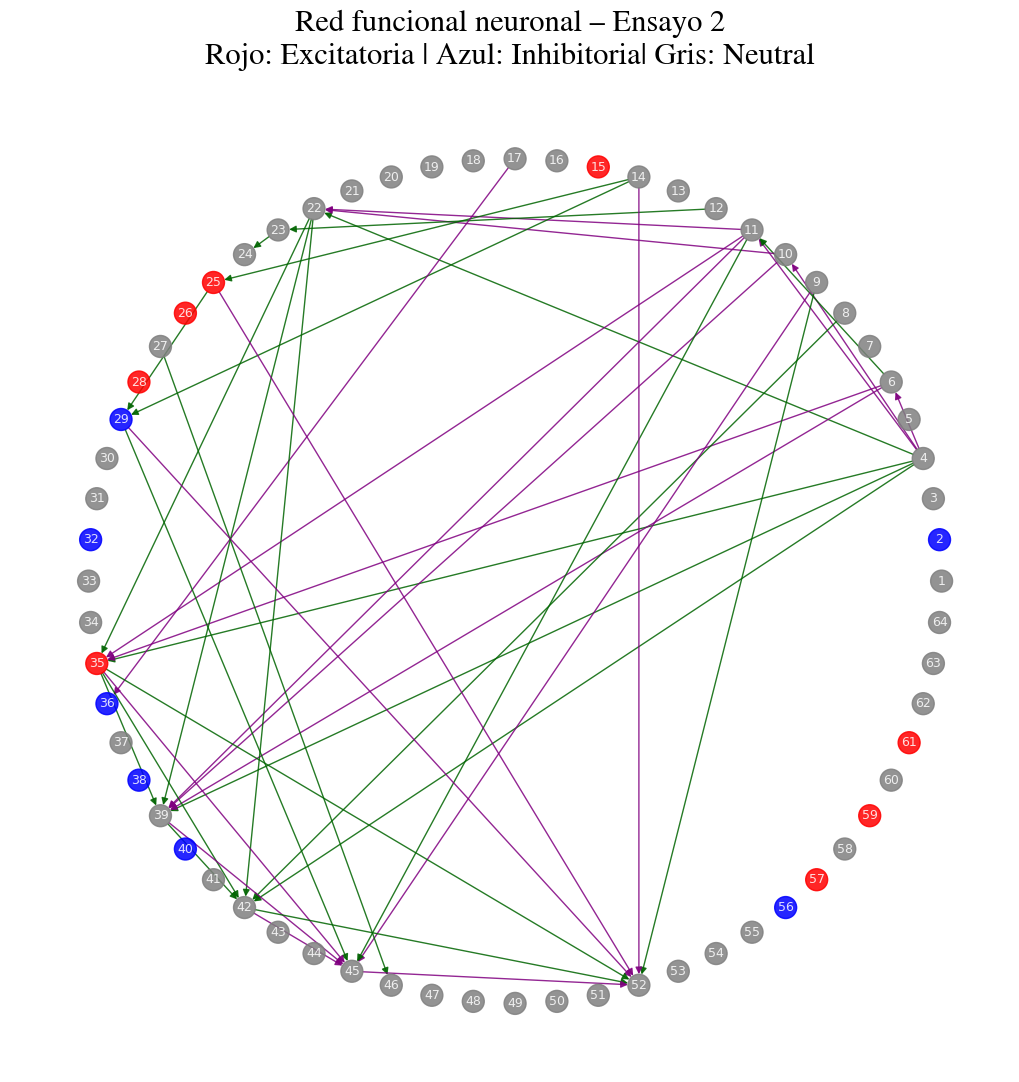

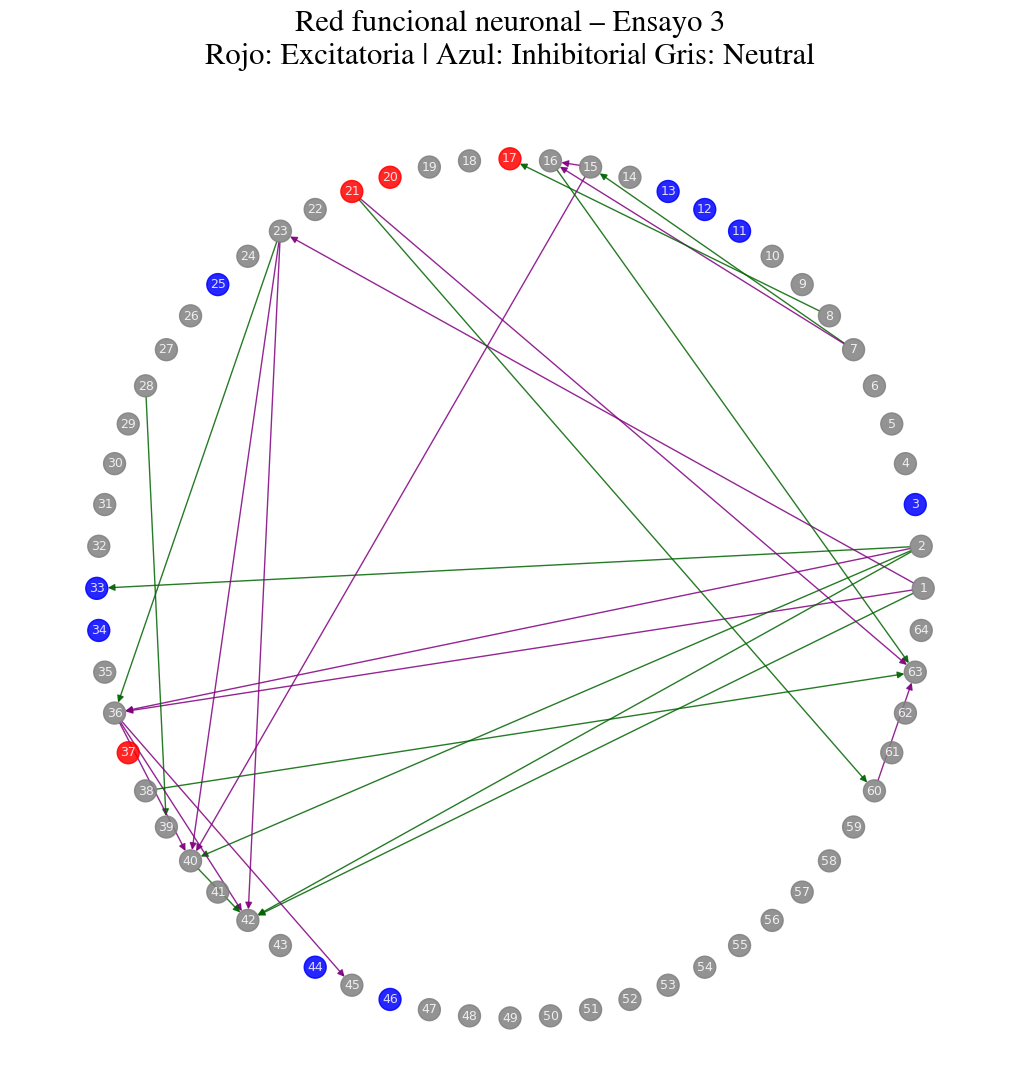

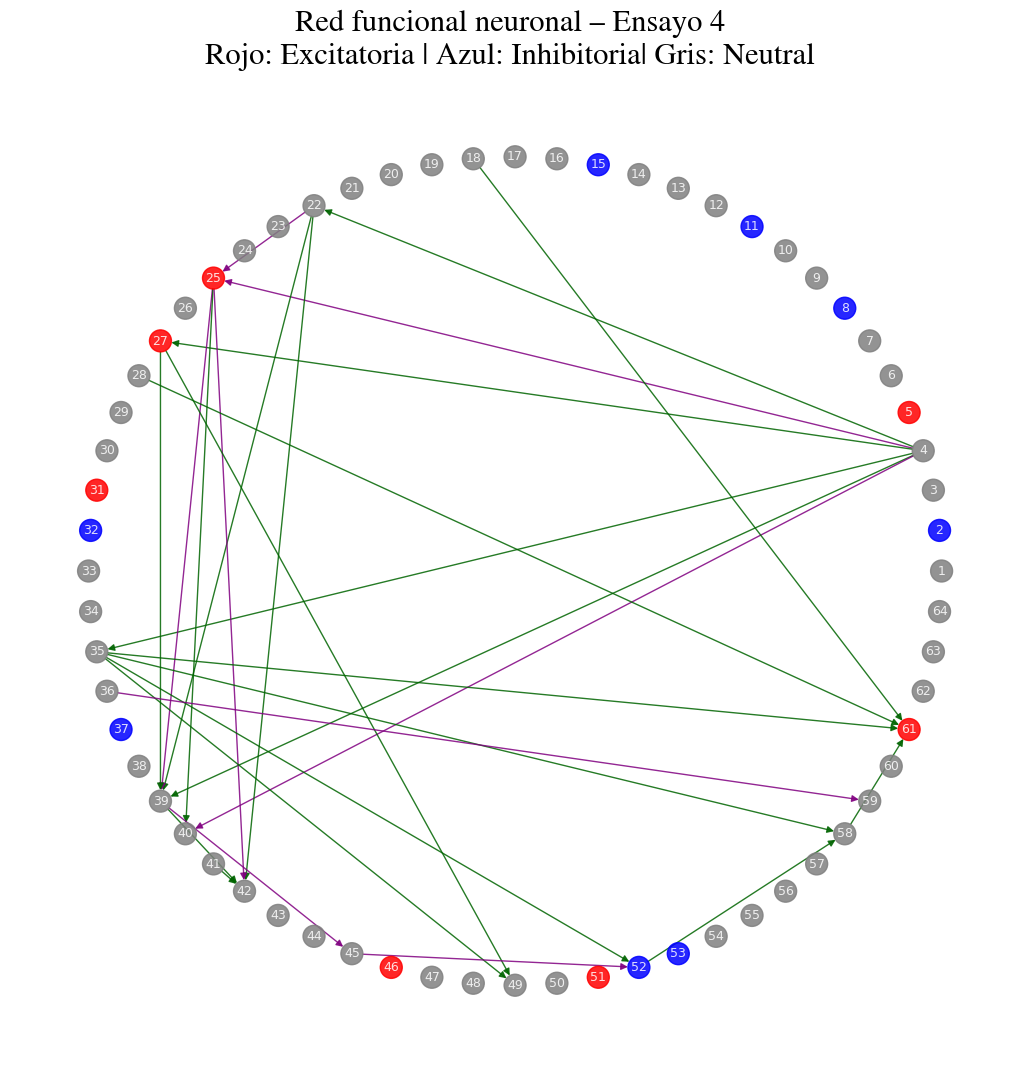

In [ ]:
for ensayo, G in red_por_ensayo.items():

  if ensayo not in [5,6]:

    plt.figure(figsize=(10,10))

    pos = nx.circular_layout(G)

    node_colors = [
          'red' if G.nodes[n]['tipo'] == 'E'
          else 'blue' if G.nodes[n]['tipo'] == 'I'
          else 'gray'
          for n in G.nodes()
          ]

    edge_colors = [
          'darkgreen' if d['weight'] > 0 else 'purple'
          for _, _, d in G.edges(data=True)
          ]

    nx.draw(
        G, pos,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=250,
        alpha=0.85,
        with_labels=True,
        font_size=9,
        font_color='white'
    )

    plt.title(f'Red funcional neuronal – Ensayo {tipos_ensayo[ensayo]}nRojo: Excitatoria | Azul: Inhibitoria| Gris: Neutral')
    plt.show()

# Desfasaje

# Funcion para elegir pares

In [ ]:
def seleccionar_pares(corr_matrix, neuronas, n_pairs=2):
      pairs_pos = []
      pairs_neg = []

      N = corr_matrix.shape[0]

      for i in range(N):
        for j in range(i+1, N):
          r = corr_matrix[i, j]
          if r > 0:
            pairs_pos.append((abs(r), r, neuronas[i], neuronas[j]))
          elif r < 0:
             pairs_neg.append((abs(r), r, neuronas[i], neuronas[j]))

      pairs_pos = sorted(pairs_pos, reverse=True)[:n_pairs]
      pairs_neg = sorted(pairs_neg, reverse=True)[:n_pairs]

      return pairs_pos, pairs_neg


In [ ]:
pares_por_ensayo = {}

for ensayo in corr_por_ensayo.keys():
    corr = corr_por_ensayo[ensayo]
    neuronas_validas = neuronas_usadas[ensayo]

    pos, neg = seleccionar_pares(corr, neuronas_validas)

    pares_por_ensayo[ensayo] = {
        'positivos': pos,
        'negativos': neg
    }


# Correlación cruzada con lag (DESFASE)

In [ ]:
def correlacion_con_lag(x, y, max_lag):
      lags = np.arange(-max_lag, max_lag+1)
      corr = []

      for lag in lags:
        if lag < 0:
           corr.append(np.corrcoef(x[:lag], y[-lag:])[0,1])
        elif lag > 0:
          corr.append(np.corrcoef(x[lag:], y[:-lag])[0,1])
        else:
           corr.append(np.corrcoef(x, y)[0,1])

      return lags, np.array(corr)


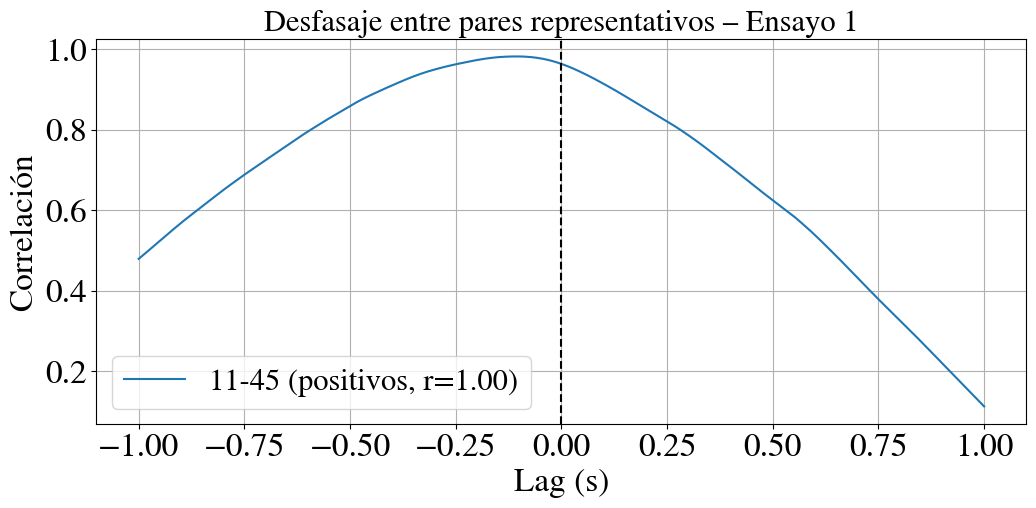

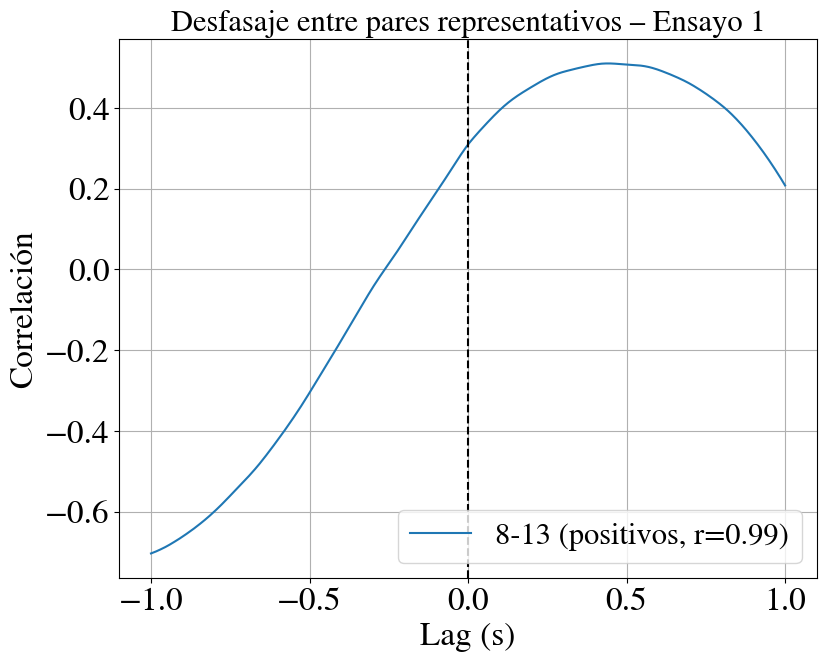

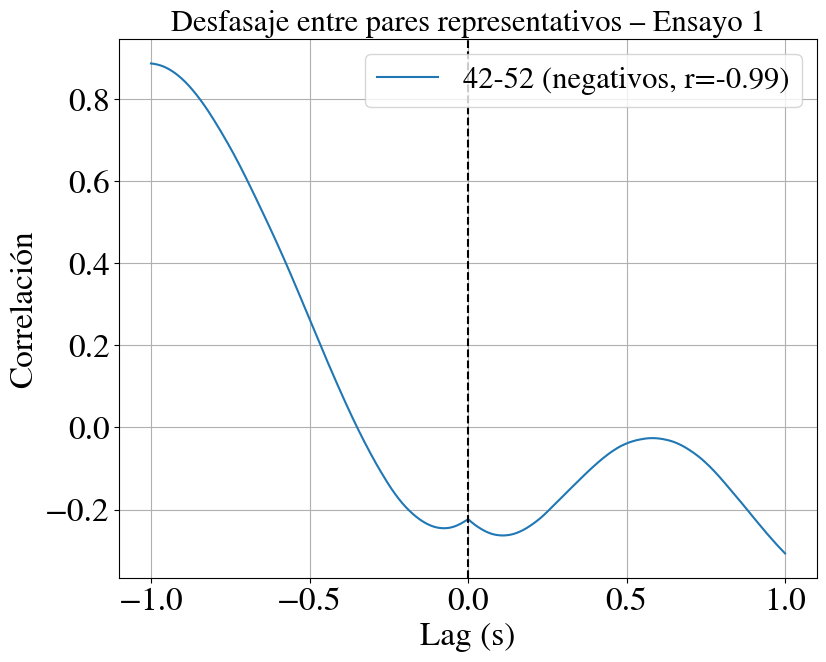

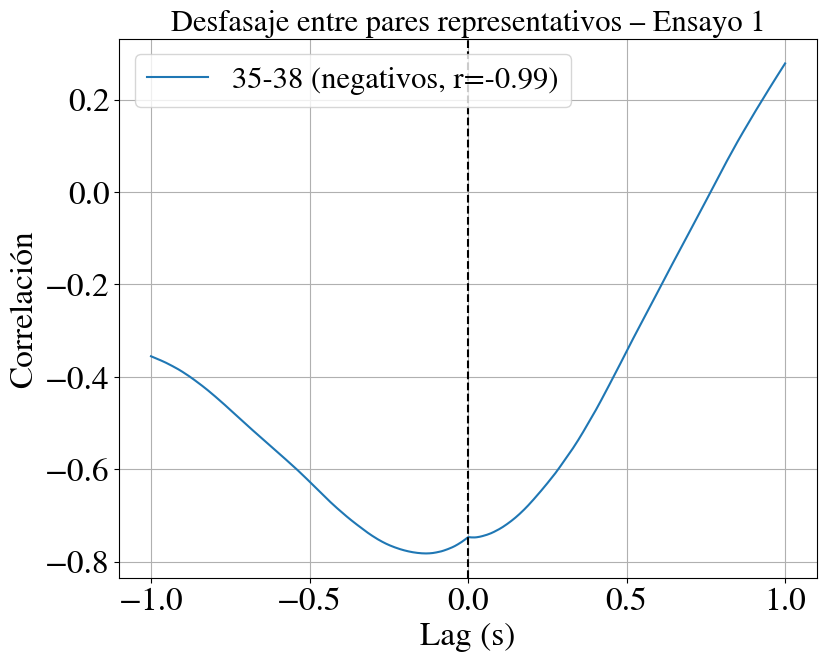

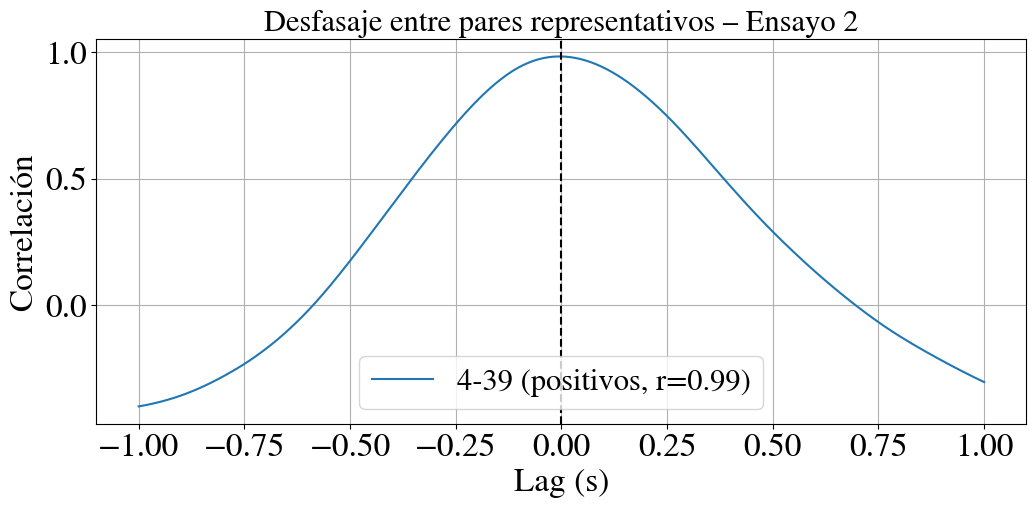

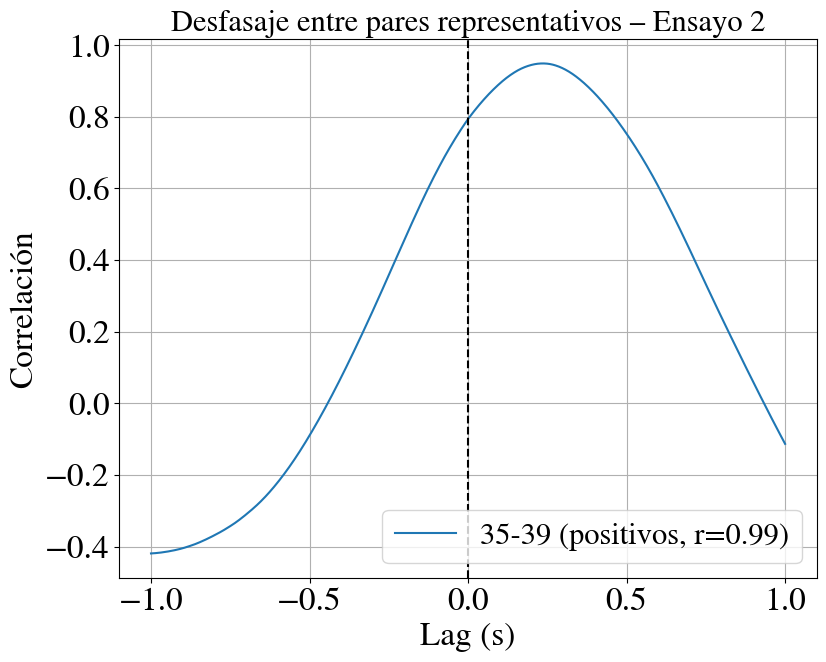

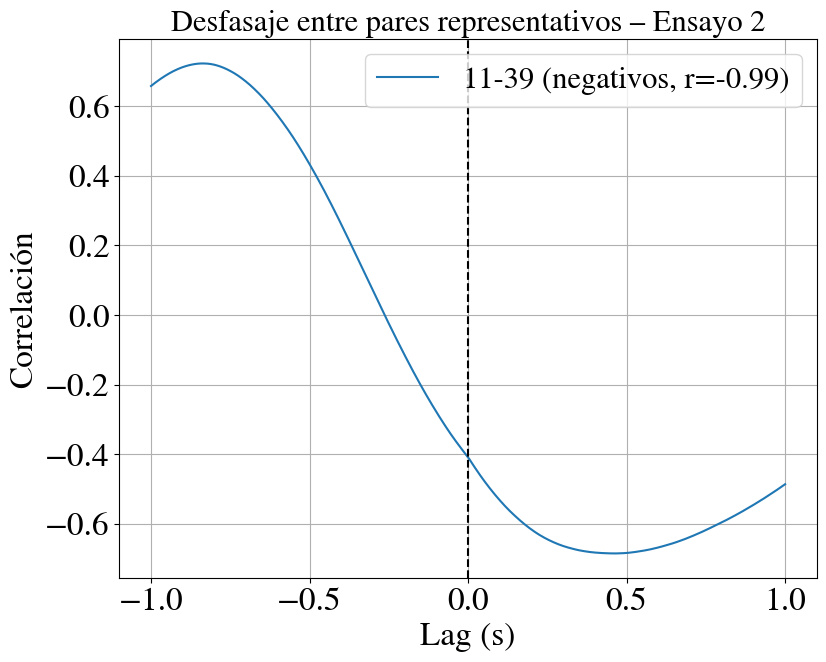

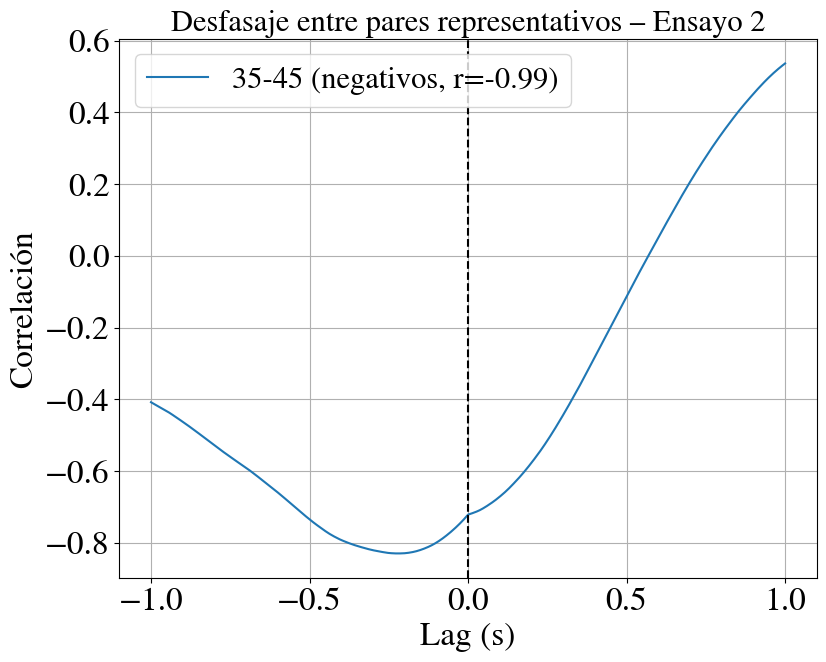

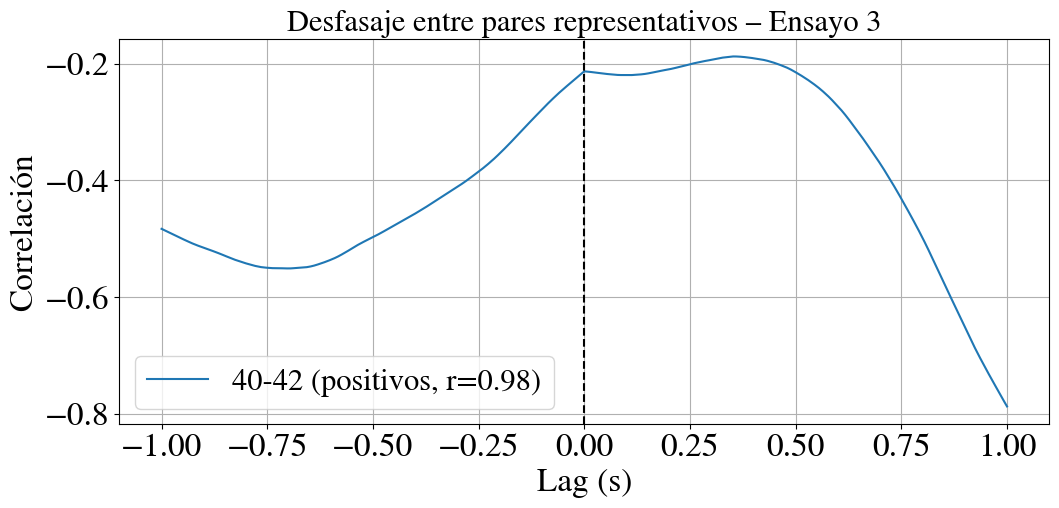

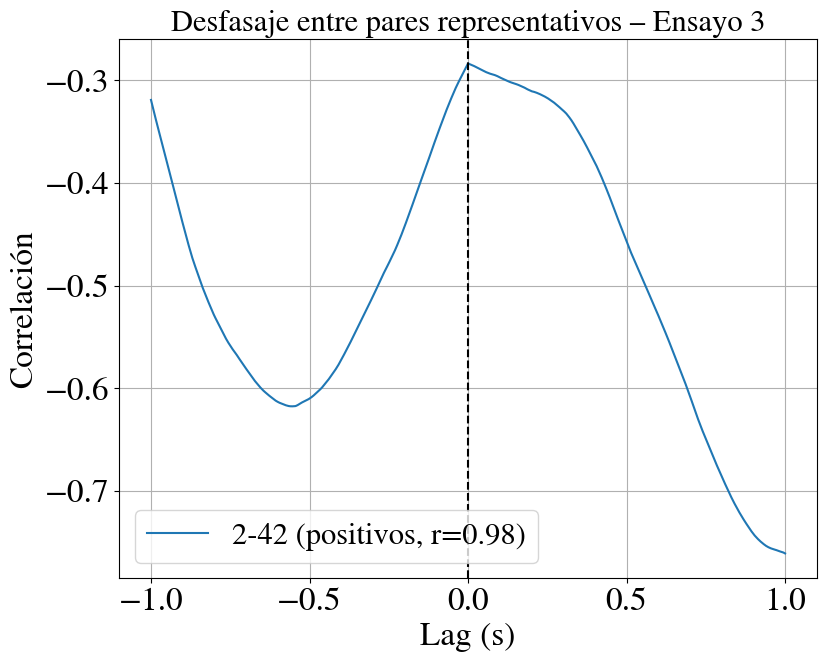

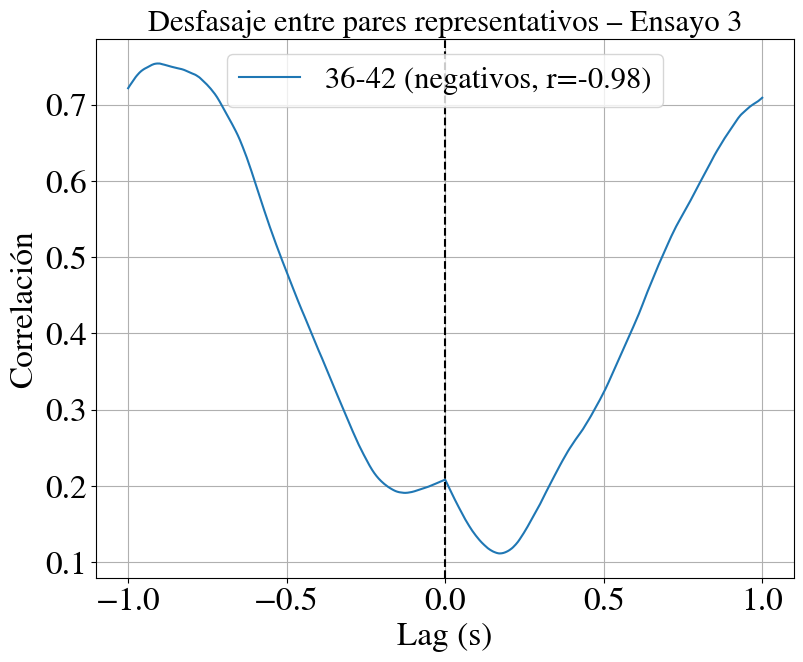

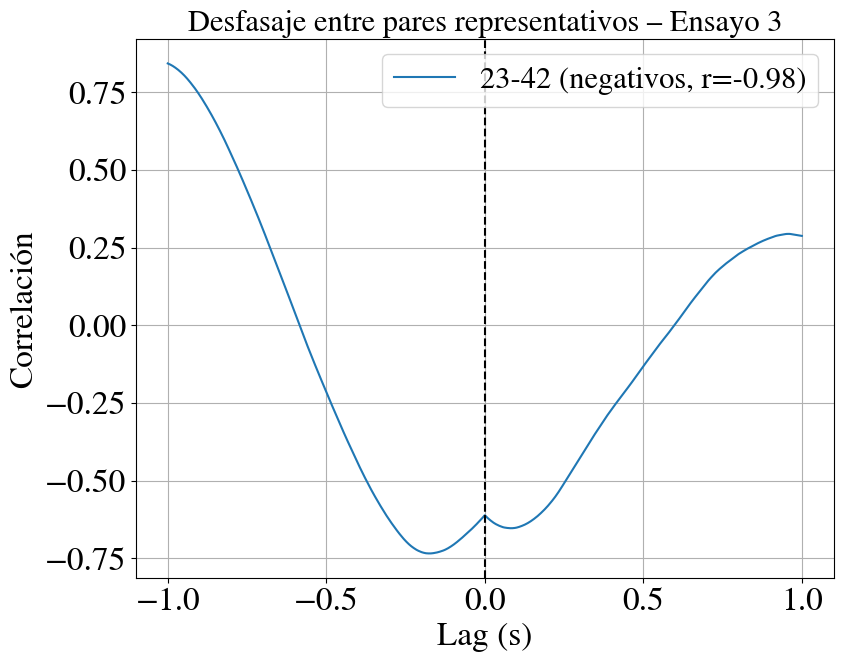

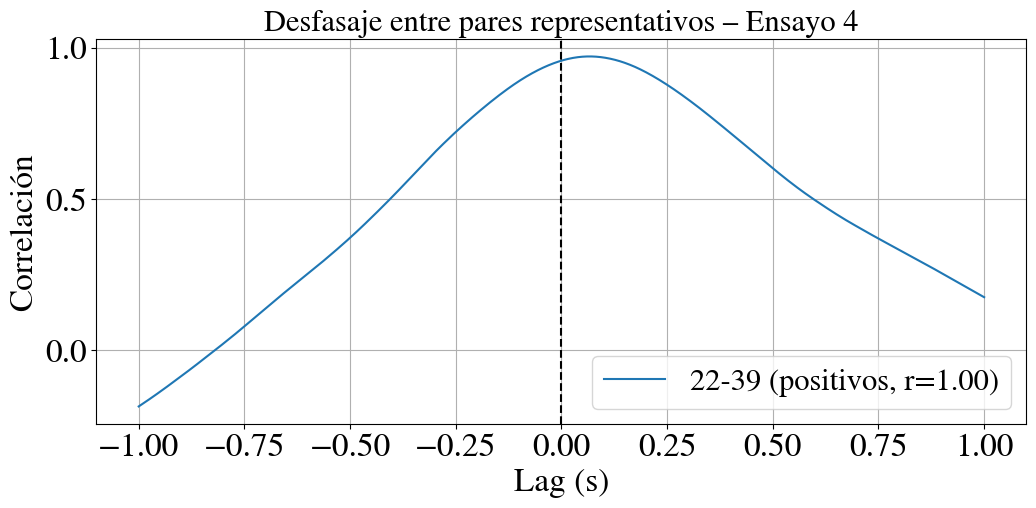

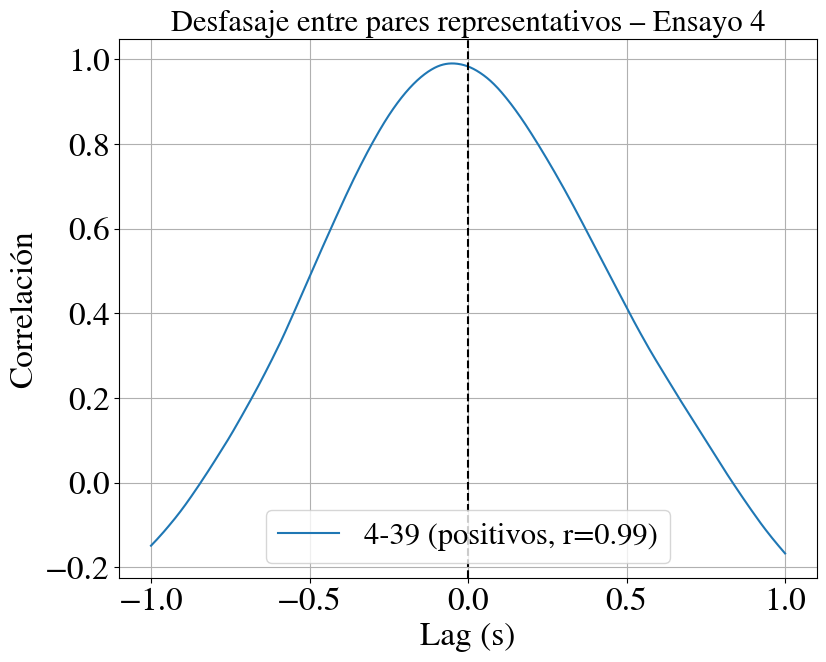

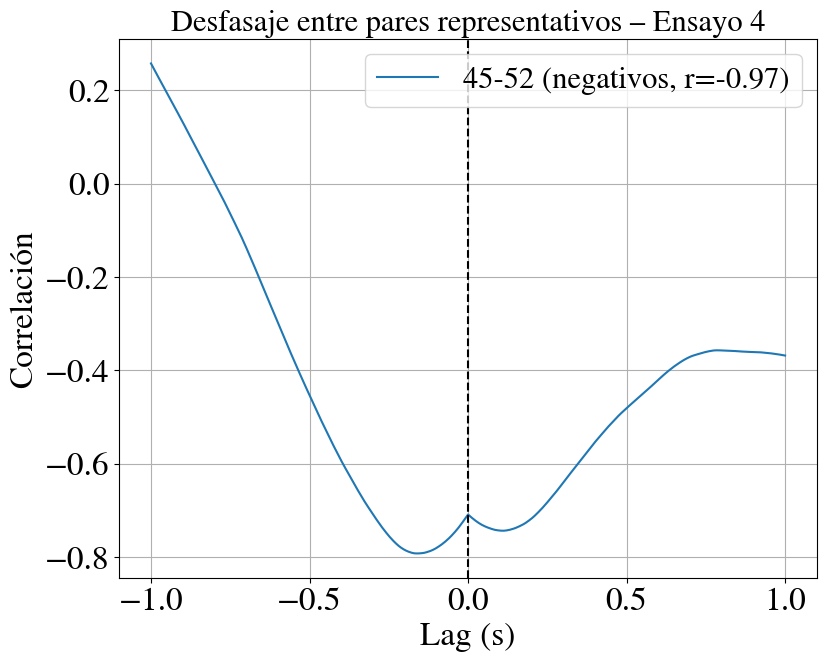

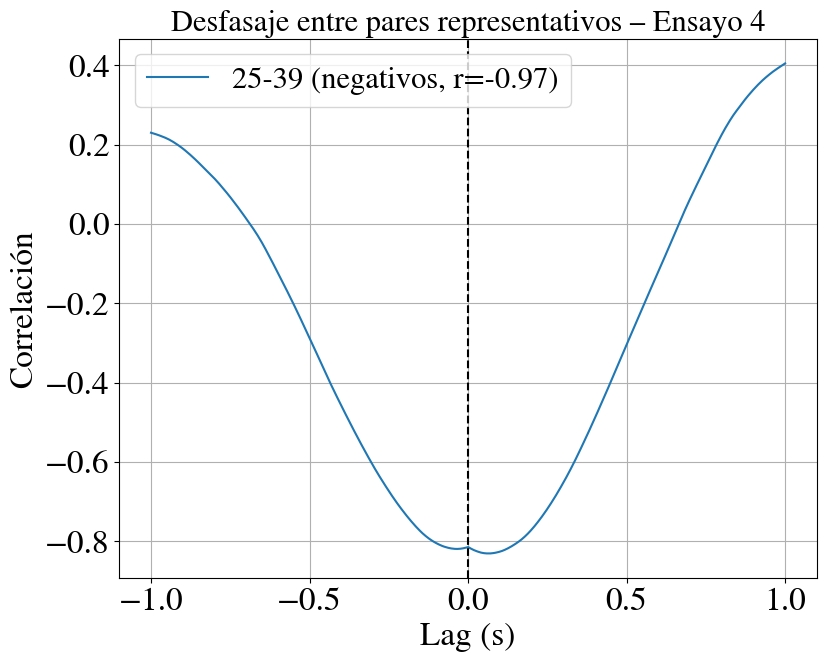

In [ ]:
max_lag = int(1 / dt)  # ±500 ms

for ensayo, pares in pares_por_ensayo.items():

  if ensayo in [5,6]:
    continue

  plt.figure(figsize=(12,5))

  for tipo, lista in pares.items():
    for _, r0, n1, n2 in lista:

      x = rates_por_neurona[n1][ensayo].mean(axis=0)
      y = rates_por_neurona[n2][ensayo].mean(axis=0)

      lags, corr_lag = correlacion_con_lag(x, y, max_lag)

      plt.plot(lags * dt, corr_lag,
               label=f'{n1}-{n2} ({tipo}, r={r0:.2f})')

      plt.axvline(0, color='k', ls='--')
      plt.xlabel('Lag (s)')
      plt.ylabel('Correlación')
      plt.title(f'Desfasaje entre pares representativos – Ensayo {ensayo}')
      plt.legend()
      plt.show()


In [ ]:
from scipy.signal import correlate

# =========================================================
# PARÁMETROS
# =========================================================

neurona_A = 4
neurona_B = 52
ensayo = 1

max_lag_s = 0.2   # 200 ms
dt = t_vector[1] - t_vector[0]
max_lag = int(max_lag_s / dt)

# =========================================================
# EXTRAER SEÑALES
# =========================================================

A = respuesta[f'Neurona {neurona_A}'][f'ensayo {ensayo}']
B = respuesta[f'Neurona {neurona_B}'][f'ensayo {ensayo}']

# quitar media (importante)
A = A - np.mean(A)
B = B - np.mean(B)

# =========================================================
# CROSS-CORRELATION
# =========================================================

corr = correlate(A, B, mode='full')
lags = np.arange(-len(A)+1, len(A)) * dt

# limitar a ventana de interés
mask = np.abs(lags) <= max_lag_s
corr = corr[mask]
lags = lags[mask]

# normalizar
corr = corr / np.max(np.abs(corr))

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8,5))
plt.plot(lags, corr)
plt.axvline(0, color='k', ls='--')
plt.xlabel("Lag (s)")
plt.ylabel("Cross-correlation (norm.)")
plt.title(f"Desfasaje Neurona {neurona_A} → {neurona_B}")
plt.show()


In [ ]:
import networkx as nx

# =========================================================
# PARÁMETROS GENERALES
# =========================================================

neurons = range(1, 65)
ensayo = 1

dt = t_vector[1] - t_vector[0]     # resolución temporal
max_lag_s = 0.05                   # ±50 ms (ajustable)
max_lag = int(max_lag_s / dt)

corr_threshold = 0.3               # umbral de correlación
lag_min_ms = 2                     # descartar |lag| < 2 ms
lag_max_ms = 20                    # rango esperado biológico

# =========================================================
# MATRICES DE RESULTADO
# =========================================================

N = len(neurons)

lag_matrix   = np.zeros((N, N)) * np.nan
peak_matrix  = np.zeros((N, N)) * np.nan

# =========================================================
# CROSS-CORRELATION PARA TODAS LAS PAREJAS
# =========================================================

for i, ni in enumerate(neurons):
    Ai = respuesta[f'Neurona {ni}'][f'ensayo {ensayo}']
    Ai = Ai - np.mean(Ai)

    for j, nj in enumerate(neurons):
        if i == j:
            continue

        Bj = respuesta[f'Neurona {nj}'][f'ensayo {ensayo}']
        Bj = Bj - np.mean(Bj)

        corr = correlate(Ai, Bj, mode='full')
        lags = np.arange(-len(Ai)+1, len(Ai)) * dt

        mask = np.abs(lags) <= max_lag_s
        corr = corr[mask]
        lags = lags[mask]

        if np.max(np.abs(corr)) == 0:
            continue

        corr = corr / np.max(np.abs(corr))

        idx_peak = np.argmax(np.abs(corr))
        lag_peak = lags[idx_peak] * 1000   # ms
        val_peak = corr[idx_peak]

        if abs(lag_peak) < lag_min_ms or abs(lag_peak) > lag_max_ms:
            continue

        if abs(val_peak) < corr_threshold:
            continue

        lag_matrix[i, j]  = lag_peak
        peak_matrix[i, j] = val_peak

# =========================================================
# HISTOGRAMA DE DESFASAJES
# =========================================================

valid_lags = lag_matrix[~np.isnan(lag_matrix)]

plt.figure(figsize=(8,5))
plt.hist(valid_lags, bins=40, color='gray', edgecolor='k')
plt.axvline(0, color='r', ls='--')
plt.xlabel("Lag del pico (ms)")
plt.ylabel("Cantidad de pares")
plt.title("Distribución de desfasajes neuronales")
plt.show()

# =========================================================
# MATRIZ DE LAGS (HEATMAP)
# =========================================================

plt.figure(figsize=(9,8))
plt.imshow(lag_matrix, cmap='coolwarm', vmin=-20, vmax=20)
plt.colorbar(label='Lag (ms)')
plt.title("Matriz neurona × neurona (desfasaje)")
plt.xlabel("Neurona B")
plt.ylabel("Neurona A")
plt.show()

# =========================================================
# CONSTRUIR RED DIRIGIDA FUNCIONAL
# =========================================================

G = nx.DiGraph()

for n in neurons:
    G.add_node(n)

for i, ni in enumerate(neurons):
    for j, nj in enumerate(neurons):
        if np.isnan(lag_matrix[i, j]):
            continue

        lag = lag_matrix[i, j]
        w   = peak_matrix[i, j]

        # Dirección: A → B si lag > 0
        if lag > 0:
            src, tgt = ni, nj
        else:
            src, tgt = nj, ni

        G.add_edge(
            src, tgt,
            weight=abs(w),
            sign='exc' if w > 0 else 'inh',
            lag=abs(lag)
        )

# =========================================================
# VISUALIZACIÓN DE LA RED
# =========================================================

plt.figure(figsize=(12,12))

pos = nx.spring_layout(G, seed=2)

edge_colors = [
    'darkgreen' if d['sign']=='exc' else 'purple'
    for _,_,d in G.edges(data=True)
]

edge_widths = [
    2 + 3*d['weight']
    for _,_,d in G.edges(data=True)
]

nx.draw(
    G, pos,
    node_size=200,
    node_color='lightgray',
    edge_color=edge_colors,
    width=edge_widths,
    with_labels=False,
    alpha=0.85
)

plt.title("Red funcional dirigida por desfasaje\nVerde: excitatoria | Violeta: inhibitoria")
plt.show()

# DESFASAJE SEPARADO POR ENSAYO

In [ ]:
# =========================================================
# PARÁMETROS GENERALES
# =========================================================

neurons = range(1, 65)
ensayos = [1, 2, 3, 4]

dt = t_vector[1] - t_vector[0]

max_lag_s = 0.05        # ±50 ms
lag_min_ms = 2          # descartar |lag| < 2 ms
lag_max_ms = 20         # rango biológico esperado

corr_threshold = 0.3    # fuerza mínima de correlación

# =========================================================
# CONTENEDORES
# =========================================================

lag_matrix_por_ensayo  = {}
peak_matrix_por_ensayo = {}
graphs_por_ensayo      = {}

# =========================================================
# LOOP POR ENSAYO
# =========================================================

for ensayo in ensayos:

    print(f"\nProcesando ensayo {ensayo}")

    N = len(neurons)
    lag_matrix  = np.full((N, N), np.nan)
    peak_matrix = np.full((N, N), np.nan)

    # -----------------------------------------------------
    # CROSS-CORRELATION ENTRE TODAS LAS PAREJAS
    # -----------------------------------------------------

    for i, ni in enumerate(neurons):

        Ai = respuesta[f'Neurona {ni}'][f'ensayo {ensayo}']
        Ai = Ai - np.mean(Ai)

        for j, nj in enumerate(neurons):

            if i == j:
                continue

            Bj = respuesta[f'Neurona {nj}'][f'ensayo {ensayo}']
            Bj = Bj - np.mean(Bj)

            corr = correlate(Ai, Bj, mode='full')
            lags = np.arange(-len(Ai)+1, len(Ai)) * dt

            mask = np.abs(lags) <= max_lag_s
            corr = corr[mask]
            lags = lags[mask]

            if np.max(np.abs(corr)) == 0:
                continue

            corr = corr / np.max(np.abs(corr))

            idx = np.argmax(np.abs(corr))
            lag_ms = lags[idx] * 1000
            peak   = corr[idx]

            if abs(lag_ms) < lag_min_ms or abs(lag_ms) > lag_max_ms:
                continue

            if abs(peak) < corr_threshold:
                continue

            lag_matrix[i, j]  = lag_ms
            peak_matrix[i, j] = peak

    lag_matrix_por_ensayo[ensayo]  = lag_matrix
    peak_matrix_por_ensayo[ensayo] = peak_matrix

    # -----------------------------------------------------
    # HISTOGRAMA DE DESFASAJES
    # -----------------------------------------------------

    valid_lags = lag_matrix[~np.isnan(lag_matrix)]

    plt.figure(figsize=(7,4))
    plt.hist(valid_lags, bins=40, color='gray', edgecolor='k')
    plt.axvline(0, color='r', ls='--')
    plt.xlabel("Lag del pico (ms)")
    plt.ylabel("Cantidad de pares")
    plt.title(f"Distribución de desfasajes – Ensayo {ensayo}")
    plt.show()

    # -----------------------------------------------------
    # MATRIZ NEURONA × NEURONA
    # -----------------------------------------------------

    plt.figure(figsize=(8,7))
    plt.imshow(lag_matrix, cmap='coolwarm', vmin=-20, vmax=20)
    plt.colorbar(label='Lag (ms)')
    plt.title(f"Matriz de desfasaje – Ensayo {ensayo}")
    plt.xlabel("Neurona B")
    plt.ylabel("Neurona A")
    plt.show()

    # -----------------------------------------------------
    # RED FUNCIONAL DIRIGIDA
    # -----------------------------------------------------

    G = nx.DiGraph()

    for n in neurons:
        G.add_node(n)

    for i, ni in enumerate(neurons):
        for j, nj in enumerate(neurons):

            if np.isnan(lag_matrix[i, j]):
                continue

            lag  = lag_matrix[i, j]
            peak = peak_matrix[i, j]

            if lag > 0:
                src, tgt = ni, nj
            else:
                src, tgt = nj, ni

            G.add_edge(
                src, tgt,
                weight=abs(peak),
                sign='exc' if peak > 0 else 'inh',
                lag=abs(lag)
            )

    graphs_por_ensayo[ensayo] = G

    plt.figure(figsize=(10,10))
    pos = nx.spring_layout(G, seed=1)

    edge_colors = [
        'darkgreen' if d['sign']=='exc' else 'purple'
        for _,_,d in G.edges(data=True)
    ]

    edge_widths = [
        2 + 3*d['weight']
        for _,_,d in G.edges(data=True)
    ]

    nx.draw(
        G, pos,
        node_size=180,
        node_color='lightgray',
        edge_color=edge_colors,
        width=edge_widths,
        with_labels=False,
        alpha=0.85
    )

    plt.title(f"Red funcional dirigida – Ensayo {ensayo}\nVerde: excitatoria | Violeta: inhibitoria")
    plt.show()